# AI3I - NCAA March Mania 2026

Solving a Kaggle competition for AI in Industry.

### Pipeline overview

| Stage | What we build | Key idea |
|-------|--------------|----------|
| **1. Load** | Raw box-score DataFrames | Men + Women unified via TeamID ranges |
| **2. Prepare** | Symmetric doubled dataset | Every game entered twice (T1↔T2 swap) |
| **3. Easy features** | Seed, Seed_diff | Expert knowledge from Selection Committee |
| **4. Medium features** | Season-average box scores + opponent averages | Team strength + defensive quality proxy |
| **5. Hard features** | Elo ratings | Cumulative win/loss momentum through the season |
| **6. Hardest features** | GLM team quality | Bradley-Terry–style coefficient estimated via Gaussian GLM |
| **7. Model** | XGBoost regression → point differential | Regression gives richer signal than binary classification |
| **8. Calibration** | Spline: point diff → probability | Non-parametric, fit on OOF tournament outcomes |
| **9. Submission** | Ensemble of LOSO models | Average predictions across all leave-one-season-out models |

### Evaluation metric

The competition rank solutions based on the **Brier score** (mean squared error between predicted probability and outcome):

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2$$

Unlike log-loss, the Brier score does **not** explode for confident wrong predictions — the maximum penalty per game is 1.0. This makes extreme predictions (e.g., 0.99 for a 1-seed vs 16-seed) less risky than under log-loss. Nonetheless, we still clip predictions to [0.01, 0.99] and invest in calibration (Section 8) to minimize overall error.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import xgboost as xgb
import optuna
from sklearn.metrics import log_loss, brier_score_loss, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import UnivariateSpline

warnings.filterwarnings("ignore")
pd.set_option("display.max_column", 999) # to visualize all the columns

/home/cico/github/march-madness/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_dir = "./march-machine-learning-mania-2026"

# M -> men's basketball
M_regular_results_df = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results_df = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds_df = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")
M_massey_ordinals_df = pd.read_csv(f"{data_dir}/MMasseyOrdinals.csv")
M_secondary_results_df = pd.read_csv(f"{data_dir}/MSecondaryTourneyCompactResults.csv")

# W -> women's basketball 
W_regular_results_df = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results_df = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds_df = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")
W_secondary_results_df = pd.read_csv(f"{data_dir}/WSecondaryTourneyCompactResults.csv")

We merge the datasets to build a stronger predictor.

In [3]:
gender = {"Men":0, "Women":1}

M_regular_results_df["Category"] = gender["Men"]
M_tourney_results_df["Category"] = gender["Men"]
W_regular_results_df["Category"] = gender["Women"]
W_tourney_results_df["Category"] = gender["Women"]

In [4]:
regular_results_df = pd.concat([M_regular_results_df, W_regular_results_df])
tourney_results_df = pd.concat([M_tourney_results_df, W_tourney_results_df])
secondary_results_df = pd.concat([M_secondary_results_df, W_secondary_results_df])
seeds_df = pd.concat([M_seeds_df, W_seeds_df])

## Data exploration

In [5]:
regular_results_df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Category
0,2003,10,1104,68,1328,62,N,0,27,58,3,14,11,18,14,24,13,23,7,1,22,22,53,2,10,16,22,10,22,8,18,9,2,20,0
1,2003,10,1272,70,1393,63,N,0,26,62,8,20,10,19,15,28,16,13,4,4,18,24,67,6,24,9,20,20,25,7,12,8,6,16,0
2,2003,11,1266,73,1437,61,N,0,24,58,8,18,17,29,17,26,15,10,5,2,25,22,73,3,26,14,23,31,22,9,12,2,5,23,0
3,2003,11,1296,56,1457,50,N,0,18,38,3,9,17,31,6,19,11,12,14,2,18,18,49,6,22,8,15,17,20,9,19,4,3,23,0
4,2003,11,1400,77,1208,71,N,0,30,61,6,14,11,13,17,22,12,14,4,4,20,24,62,6,16,17,27,21,15,12,10,7,1,14,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87182,2026,131,3471,60,3218,48,N,0,25,69,3,16,7,8,8,27,13,7,11,1,9,18,48,4,16,8,8,2,31,9,17,3,6,15,1
87183,2026,132,3158,68,3220,56,N,0,23,61,9,27,13,21,16,26,12,9,5,1,12,23,58,7,21,3,5,9,25,10,13,2,4,17,1
87184,2026,132,3192,79,3254,57,H,0,31,60,10,19,7,11,9,32,15,10,4,1,18,19,55,7,20,12,14,5,19,2,11,5,4,15,1
87185,2026,132,3221,77,3250,70,H,0,31,60,5,17,10,12,13,23,16,12,3,4,10,26,55,9,24,9,12,8,17,17,11,6,2,12,1


In [6]:
tourney_results_df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,WFGM3,WFGA3,WFTM,WFTA,WOR,WDR,WAst,WTO,WStl,WBlk,WPF,LFGM,LFGA,LFGM3,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF,Category
0,2003,134,1421,92,1411,84,N,1,32,69,11,29,17,26,14,30,17,12,5,3,22,29,67,12,31,14,31,17,28,16,15,5,0,22,0
1,2003,136,1112,80,1436,51,N,0,31,66,7,23,11,14,11,36,22,16,10,7,8,20,64,4,16,7,7,8,26,12,17,10,3,15,0
2,2003,136,1113,84,1272,71,N,0,31,59,6,14,16,22,10,27,18,9,7,4,19,25,69,7,28,14,21,20,22,11,12,2,5,18,0
3,2003,136,1141,79,1166,73,N,0,29,53,3,7,18,25,11,20,15,18,13,1,19,27,60,7,17,12,17,14,17,20,21,6,6,21,0
4,2003,136,1143,76,1301,74,N,1,27,64,7,20,15,23,18,20,17,13,8,2,14,25,56,9,21,15,20,10,26,16,14,5,8,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,2025,147,3163,78,3425,64,N,0,27,60,10,22,14,17,3,25,16,12,10,2,17,19,58,3,13,23,26,9,26,7,15,8,2,18,1
957,2025,147,3400,58,3395,47,N,0,24,61,2,3,8,11,8,21,14,7,9,6,20,12,45,4,20,19,21,9,21,8,16,1,3,14,1
958,2025,151,3163,85,3417,51,N,0,33,60,7,16,12,17,4,23,17,7,13,2,16,20,52,4,16,7,8,6,20,11,18,5,2,12,1
959,2025,151,3376,74,3400,57,N,0,29,57,7,11,9,12,8,22,17,13,7,5,15,22,56,4,10,9,12,8,18,10,14,6,5,17,1


In [7]:
seeds_df

,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374
...,...,...,...
1807,2026,Z12,3211
1808,2026,Z13,3453
1809,2026,Z14,3158
1810,2026,Z15,3239


In [8]:
secondary_results_df

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,SecondaryTourney
0,1985,136,1151,67,1155,65,H,0,NIT
1,1985,136,1153,77,1245,61,H,0,NIT
2,1985,136,1201,79,1365,76,H,0,NIT
3,1985,136,1231,79,1139,57,H,0,NIT
4,1985,136,1249,78,1222,71,H,0,NIT
...,...,...,...,...,...,...,...,...,...
901,2025,147,3407,97,3295,88,A,1,WNIT
902,2025,149,3138,74,3156,69,H,0,WNIT
903,2025,149,3278,75,3125,63,N,0,WBIT
904,2025,149,3407,99,3229,96,A,0,WNIT


Massey ordinals contains ranking assigned by external systems. It exists for men's competition only

In [9]:
M_massey_ordinals_df

,Season,RankingDayNum,SystemName,TeamID,OrdinalRank
0,2003,35,SEL,1102,159
1,2003,35,SEL,1103,229
2,2003,35,SEL,1104,12
3,2003,35,SEL,1105,314
4,2003,35,SEL,1106,260
...,...,...,...,...,...
5864996,2026,133,WLS,1477,318
5864997,2026,133,WLS,1478,303
5864998,2026,133,WLS,1479,287
5864999,2026,133,WLS,1480,293


Do we have nan values?

In [10]:
print("NaN values?")
print("")
print(f"Regular Season results: {any(regular_results_df.isna().any())}")
print(f"Tourney results:        {any(tourney_results_df.isna().any())}")
print(f"Secondary results:      {any(secondary_results_df.isna().any())}")
print(f"Ordinal rankings:       {any(M_massey_ordinals_df.isna().any())}")

NaN values?

Regular Season results: False
Tourney results:        False
Secondary results:      False
Ordinal rankings:       False


Do we have missing values?

In [11]:
print("Missing values?")
print("")
print(f"Regular Season results: {not int(regular_results_df.describe().loc["count"].unique().item()) == len(regular_results_df)}")
print(f"Tourney results:        {not int(tourney_results_df.describe().loc["count"].unique().item()) == len(tourney_results_df)}")
print(f"Secondary results:      {not int(secondary_results_df.describe().loc["count"].unique().item()) == len(secondary_results_df)}")
print(f"Ordinal rankings:       {not int(M_massey_ordinals_df.describe().loc["count"].unique().item()) == len(M_massey_ordinals_df)}")


Missing values?

Regular Season results: False
Tourney results:        False
Secondary results:      False
Ordinal rankings:       False


Let's see the journey of a team during last season

In [12]:
season = 2025
team_id = 1104

In [13]:
r = regular_results_df[
    (regular_results_df["Season"]==season) & 
    ((regular_results_df["WTeamID"]==team_id) | (regular_results_df["LTeamID"]==team_id))]

t = tourney_results_df[
    (tourney_results_df["Season"]==season) & 
    ((tourney_results_df["WTeamID"]==team_id) | (tourney_results_df["LTeamID"]==team_id))]

r["Type"] = "regular season"
t["Type"] = "tournament"

rt = pd.concat([r,t])
rt["Outcome"] = np.where(rt["WTeamID"] == team_id, "win", "lose")

rt[["DayNum", "WScore", "LScore", "Type", "Outcome"]]

,DayNum,WScore,LScore,Type,Outcome
113241,0,110,54,regular season,win
113411,4,88,79,regular season,win
113547,7,72,64,regular season,win
113724,11,87,78,regular season,lose
113916,16,100,87,regular season,win
114219,22,85,80,regular season,win
114275,23,95,90,regular season,win
114447,26,83,81,regular season,lose
114563,30,94,79,regular season,win
114859,40,83,75,regular season,win


Building shooting percentage to check their distribution

In [14]:
rt["WFG%"] = rt["WFGM"]/rt["WFGA"]
rt["WFG%3"] = rt["WFGM3"]/rt["WFGA3"]
rt["WFT%"] = rt["WFTM"]/rt["WFTA"]

rt["LFG%"] = rt["LFGM"]/rt["LFGA"]
rt["LFG%3"] = rt["LFGM3"]/rt["LFGA3"]
rt["LFT%"] = rt["LFTM"]/rt["LFTA"]

Checking shooting stats of won matches

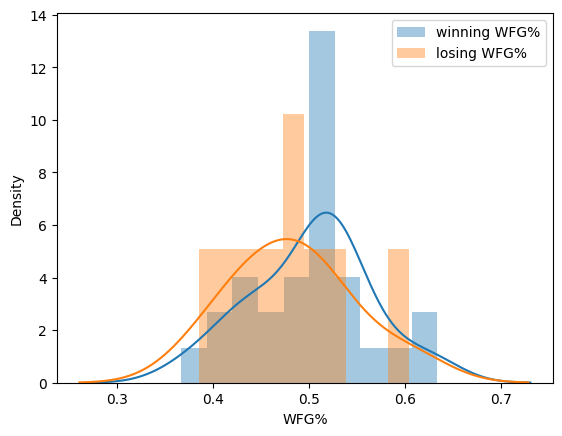

In [15]:
s1 = rt[rt["Outcome"]=="win"]["WFG%"]
s2 = rt[rt["Outcome"]=="lose"]["WFG%"]
seaborn.distplot(s1, label="winning WFG%", bins=10, kde=True)
seaborn.distplot(s2, label="losing WFG%", bins=10, kde=True)
plt.legend()

In [16]:
rt[rt["Outcome"]=="win"][["WFGM","WFGA","WFG%","WFGM3","WFGA3","WFG%3","WFTM","WFTA","WFT%"]].describe()

,WFGM,WFGA,WFG%,WFGM3,WFGA3,WFG%3,WFTM,WFTA,WFT%
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,32.142857,64.214286,0.501690,11.035714,30.142857,0.362849,18.678571,25.964286,0.731941
std,4.624526,6.718450,0.062943,4.857085,9.224421,0.088256,5.786661,8.625896,0.108069
min,22.000000,50.000000,0.366667,5.000000,17.000000,0.193548,10.000000,13.000000,0.500000
25%,29.750000,60.000000,0.449440,7.750000,22.750000,0.316223,15.000000,20.000000,0.666667
50%,33.500000,63.500000,0.517549,11.000000,30.000000,0.359238,18.000000,24.000000,0.732520
75%,35.250000,68.500000,0.527313,12.250000,34.000000,0.414087,22.250000,34.000000,0.827899
max,39.000000,78.000000,0.633333,25.000000,55.000000,0.586207,30.000000,44.000000,0.923077


Checking shooting stats of lost matches

In [17]:
rt[rt["Outcome"]=="lose"][["LFGM","LFGA","LFG%","LFGM3","LFGA3","LFG%3","LFTM","LFTA","LFT%"]].describe()

,LFGM,LFGA,LFG%,LFGM3,LFGA3,LFG%3,LFTM,LFTA,LFT%
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,27.444444,63.666667,0.430741,9.000000,28.888889,0.309676,16.444444,22.777778,0.730701
std,4.772607,7.211103,0.052346,2.783882,5.710614,0.070521,4.275252,6.359595,0.067958
min,20.000000,47.000000,0.353846,5.000000,20.000000,0.192308,11.000000,14.000000,0.652174
25%,25.000000,63.000000,0.416667,8.000000,25.000000,0.250000,15.000000,20.000000,0.680000
50%,27.000000,65.000000,0.421875,9.000000,29.000000,0.314286,15.000000,23.000000,0.730769
75%,28.000000,67.000000,0.444444,11.000000,32.000000,0.360000,17.000000,26.000000,0.750000
max,35.000000,72.000000,0.538462,13.000000,38.000000,0.419355,26.000000,35.000000,0.866667


Which seeds did our team have? Which average ordinal ranking?

In [18]:
seeds_df[(seeds_df["Season"]==season) & (seeds_df["TeamID"]==team_id)]

,Season,Seed,TeamID
2559,2025,W02,1104


The OrdinalRank mean across al systems of teamid=1104 during season 2025, grouped per ranking day

In [19]:
M_massey_ordinals_df[(M_massey_ordinals_df["Season"]==season) & (M_massey_ordinals_df["TeamID"]==1104)].groupby("RankingDayNum")["OrdinalRank"].mean().reset_index().tail(5)

,RankingDayNum,OrdinalRank
14,107,4.173077
15,114,5.094340
16,121,4.981818
17,128,5.035714
18,133,5.553571


We want to extract the mean of the last 5 games and use it as a feature

In [20]:
grouped_ordinals = M_massey_ordinals_df.groupby(["Season","TeamID","RankingDayNum"])["OrdinalRank"].mean().reset_index()

In [21]:
M_ordinals = pd.DataFrame(columns=["Season","TeamID","LateSeasonRank"])
seasons, team_ids, late_season_ranks = [],[],[]
for season in grouped_ordinals["Season"].unique():
    for team_id in grouped_ordinals[grouped_ordinals["Season"]==season]["TeamID"].unique():
        seasons.append(season)
        team_ids.append(team_id)
        late_season_ranks.append(
            grouped_ordinals[(grouped_ordinals["Season"]==season) & (grouped_ordinals["TeamID"]==team_id)]["OrdinalRank"][-5:].mean()
        )

M_ordinals["Season"] = seasons
M_ordinals["TeamID"] = team_ids
M_ordinals["LateSeasonRank"] = late_season_ranks

In [22]:
M_ordinals[M_ordinals["TeamID"]==1112]

,Season,TeamID,LateSeasonRank
9,2003,1112,1.701961
336,2004,1112,31.695238
662,2005,1112,11.046504
992,2006,1112,37.785789
1326,2007,1112,17.815273
1662,2008,1112,36.315450
2004,2009,1112,46.880584
2351,2010,1112,90.363961
2698,2011,1112,20.091855
3043,2012,1112,56.378820


### Ranking stats

Seeds describe team's ranking (according to experts) based on their prior performance throughout the regular season. They are alphanumeric strings, with the first character determining the region of the team. An additional letter is added to distinguish teams belonging to the same region. We will use only the digits of the seed to represent their ranking.

NB: only tournament's teams are assigned with a seed

In [23]:
[x for x in seeds_df["Seed"].unique()]

['W01',
 'W02',
 'W03',
 'W04',
 'W05',
 'W06',
 'W07',
 'W08',
 'W09',
 'W10',
 'W11',
 'W12',
 'W13',
 'W14',
 'W15',
 'W16',
 'X01',
 'X02',
 'X03',
 'X04',
 'X05',
 'X06',
 'X07',
 'X08',
 'X09',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'Y01',
 'Y02',
 'Y03',
 'Y04',
 'Y05',
 'Y06',
 'Y07',
 'Y08',
 'Y09',
 'Y10',
 'Y11',
 'Y12',
 'Y13',
 'Y14',
 'Y15',
 'Y16',
 'Z01',
 'Z02',
 'Z03',
 'Z04',
 'Z05',
 'Z06',
 'Z07',
 'Z08',
 'Z09',
 'Z10',
 'Z11',
 'Z12',
 'Z13',
 'Z14',
 'Z15',
 'Z16',
 'Y16a',
 'Y16b',
 'W16a',
 'W16b',
 'X16a',
 'X16b',
 'Z16a',
 'Z16b',
 'W12a',
 'W12b',
 'Z11a',
 'Z11b',
 'X12a',
 'X12b',
 'Z14a',
 'Z14b',
 'Y11a',
 'Y11b',
 'Z13a',
 'Z13b',
 'Y12a',
 'Y12b',
 'W11a',
 'W11b',
 'X11a',
 'X11b',
 'Y10a',
 'Y10b',
 'Z10a',
 'Z10b',
 'Z12a',
 'Z12b',
 'X10a',
 'X10b']

Some games do not end at the regular time and 1 or more OT are played. This means that stats are collected for a longer time (higher scored points, rebounds, etc.)

<Axes: xlabel='NumOT'>

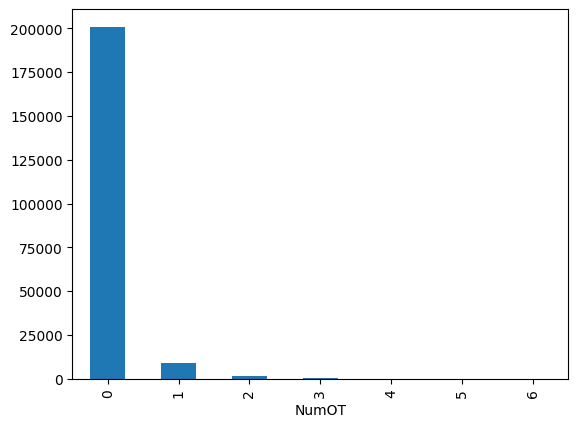

In [24]:
regular_results_df["NumOT"].value_counts().plot(kind="bar")

Is winning at home easier than winning away?

<Axes: xlabel='WLoc'>

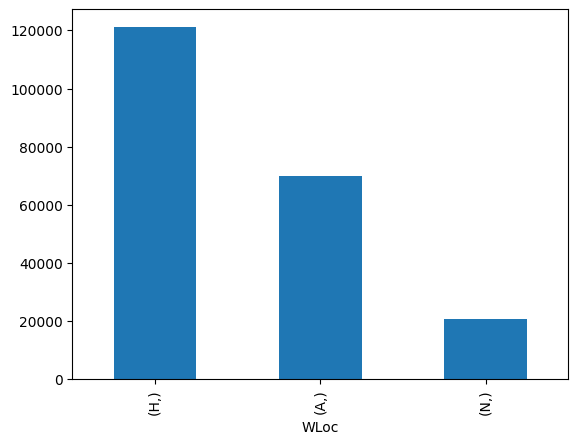

In [25]:
regular_results_df[["WLoc"]].value_counts().plot(kind="bar")

3 ways to plot the same distribution!

In [26]:
s1 = regular_results_df[regular_results_df["WLoc"]== "H"]["WScore"]
s2 = regular_results_df[regular_results_df["WLoc"]== "A"]["WScore"]

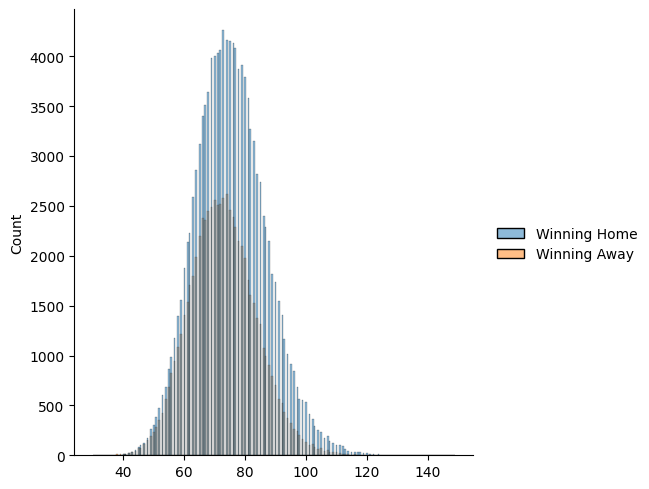

In [27]:
tmp = pd.DataFrame()
tmp["Winning Home"] = s1.reset_index(drop=True)
tmp["Winning Away"] = s2.reset_index(drop=True)
seaborn.displot(tmp, kind="hist")

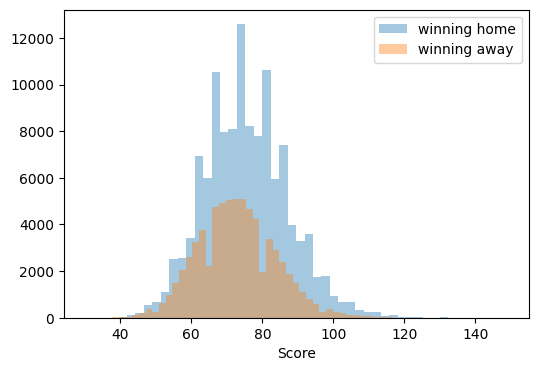

In [28]:
plt.figure(figsize=(6,4))
seaborn.distplot(s1, label="winning home", kde=False)
seaborn.distplot(s2, label="winning away", kde=False)
plt.xlabel("Score")
plt.legend()

we can take into account the home advantage by correcting the raw scores with the mean differences. 

In [29]:
home_score_mean = s1.mean()
away_score_mean = s2.mean()
home_advantage = (home_score_mean - away_score_mean)/2

print(f"The mean score when winning home is: {home_score_mean}")
print(f"The mean score when winning away is: {away_score_mean}")
print("")
print(f"Mean home advantage points is: {home_score_mean - away_score_mean}")

The mean score when winning home is: 75.3961703532519
The mean score when winning away is: 72.77674365325964

Mean home advantage points is: 2.6194266999922604


Shooting percentages should capture better the average performance of a team throughout a season

In [30]:
rr = regular_results_df.copy()

rr["WFG%"] = rr["WFGM"]/rr["WFGA"]
rr["WFG%3"] = rr["WFGM3"]/rr["WFGA3"]
rr["WFT%"] = rr["WFTM"]/rr["WFTA"]

rr["LFG%"] = rr["LFGM"]/rr["LFGA"]
rr["LFG%3"] = rr["LFGM3"]/rr["LFGA3"]
rr["LFT%"] = rr["LFTM"]/rr["LFTA"]

In [31]:
columns_to_describe = ['WScore','LScore','WLoc','WFGM','WFGA','WFG%',
                       'WFGM3','WFGA3','WFG%3','WFTM','WFTA','WFT%','WOR',
                       'WDR','WAst','WTO','WStl','WBlk','WPF',
                       'LFGM','LFGA','LFG%','LFGM3','LFGA3','LFG%3',
                       'LFTM','LFTA','LFT%','LOR','LDR','LAst','LTO',
                       'LStl','LBlk','LPF']
winning_teams_columns = [c for c in columns_to_describe if c.startswith("W")]
losing_teams_columns = [c for c in columns_to_describe if c.startswith("L")]

In [32]:
rr[winning_teams_columns].describe()

,WScore,WFGM,WFGA,WFG%,WFGM3,WFGA3,WFG%3,WFTM,WFTA,WFT%,WOR,WDR,WAst,WTO,WStl,WBlk,WPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211702.000000,211716.000000,211716.000000,211688.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,74.347182,26.237209,57.166081,0.460710,6.963810,18.940973,0.365366,14.908954,20.851622,0.715244,10.973960,25.962469,14.838156,13.492216,7.672505,3.732968,16.683028
std,11.458923,4.821583,7.811166,0.068897,3.183975,6.366821,0.117219,6.112946,7.971070,0.118703,4.461546,5.090498,4.530240,4.464958,3.495792,2.417302,4.214254
min,30.000000,9.000000,26.000000,0.180000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,66.000000,23.000000,52.000000,0.413793,5.000000,14.000000,0.285714,11.000000,15.000000,0.642857,8.000000,22.000000,12.000000,10.000000,5.000000,2.000000,14.000000
50%,74.000000,26.000000,57.000000,0.459459,7.000000,19.000000,0.363636,14.000000,20.000000,0.722222,11.000000,26.000000,15.000000,13.000000,7.000000,3.000000,16.000000
75%,82.000000,29.000000,62.000000,0.508197,9.000000,23.000000,0.441176,19.000000,26.000000,0.800000,14.000000,29.000000,18.000000,16.000000,10.000000,5.000000,19.000000
max,149.000000,58.000000,113.000000,0.800000,30.000000,63.000000,1.000000,50.000000,67.000000,1.000000,45.000000,58.000000,45.000000,40.000000,36.000000,21.000000,42.000000


In [33]:
rr[losing_teams_columns].describe()

,LScore,LFGM,LFGA,LFG%,LFGM3,LFGA3,LFG%3,LFTM,LFTA,LFT%,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
count,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211709.000000,211716.000000,211716.000000,211581.000000,211716.00000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000,211716.000000
mean,61.307204,22.055338,57.335029,0.386048,5.734385,19.376311,0.292827,11.462143,16.826839,0.679926,10.68812,21.860960,11.232481,15.130113,6.462365,2.850262,18.797054
std,11.413701,4.498934,7.725899,0.067848,2.822170,6.359618,0.109315,5.248387,6.986135,0.138866,4.40488,4.704645,3.770125,5.044259,2.985238,2.033009,4.585103
min,11.000000,3.000000,25.000000,0.060000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,54.000000,19.000000,52.000000,0.339623,4.000000,15.000000,0.222222,8.000000,12.000000,0.600000,8.00000,19.000000,9.000000,12.000000,4.000000,1.000000,16.000000
50%,61.000000,22.000000,57.000000,0.385965,5.000000,19.000000,0.291667,11.000000,16.000000,0.687500,10.00000,22.000000,11.000000,15.000000,6.000000,3.000000,19.000000
75%,69.000000,25.000000,62.000000,0.431373,8.000000,23.000000,0.363636,15.000000,21.000000,0.772727,13.00000,25.000000,14.000000,18.000000,8.000000,4.000000,22.000000
max,144.000000,53.000000,111.000000,0.727273,25.000000,80.000000,1.000000,48.000000,65.000000,1.000000,38.00000,53.000000,34.000000,49.000000,26.000000,18.000000,47.000000


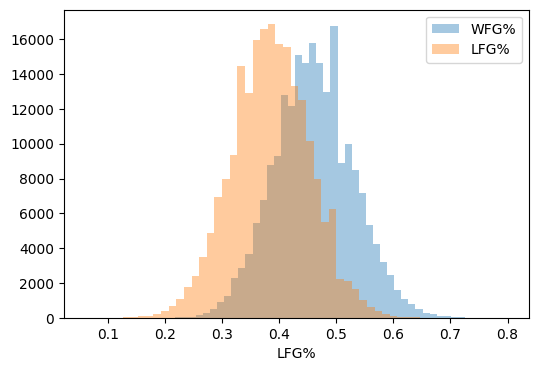

In [34]:
s1 = rr["WFG%"].reset_index(drop=True)
s2 = rr["LFG%"].reset_index(drop=True)

plt.figure(figsize=(6,4))
seaborn.distplot(s1, label="WFG%", kde=False)
seaborn.distplot(s2, label="LFG%", kde=False)
plt.legend()

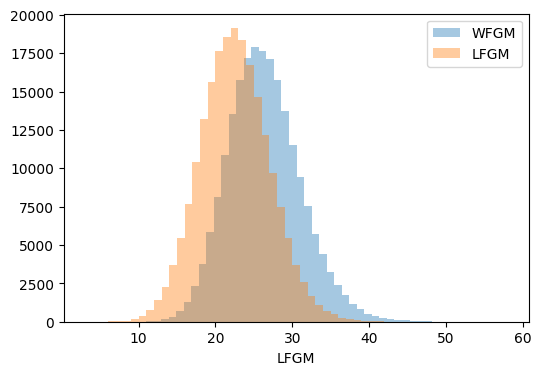

In [35]:
s1 = rr["WFGM"]
s2 = rr["LFGM"]

plt.figure(figsize=(6,4))
seaborn.distplot(s1, label="WFGM", kde=False)
seaborn.distplot(s2, label="LFGM", kde=False)
plt.legend()

### to do: study the correlation between computed features (shooting percentage, quality, efficiency, etc.) and the variable we want to predict (points difference)
we can do this once we have create all our features and merged them in the tourney_results.  
is this feature importance?

### to do: build the ordinal ranking for women from other features.
we can do this once we have create all our features and merged them in the tourney_results

## Data preparation
Our current dataset is on the POV of winners: WTeam is always the winning team, and this might not be ideal for our predictions (which are inherently ordered). We want our model to be independent on the order of teams: we will process our dataset so to contain T1_stats and T2_stats, where T1 and T2 order do not determine the vicory.

We will duplicate our dataset, each match will appear twice, and each team will be one time T1 and one time T2.

Given the high number of matches with NumOT > 0, we will also apply an adjustment to take into account more stats collected:

$$\text{adjusted stat} = \text{raw stat} \times \frac{40}{40 + 5 \times \text{NumOT}}$$

Since we need to output a probability for each match, we will use the point difference as a target. It is easy and more explainable to transform a (continuous) margin of victory into a probability of winning, rather than a binary outcome.


In [36]:
def prepare_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    columns_to_adjust = ['WScore', 'LScore', 'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR',
        'WAst', 'WTO', 'WStl', 'WBlk', 'WPF', 'LFGM', 'LFGA', 'LFGM3', 'LFGA3',
        'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF']
    adjust_coeff = 40 / (df["NumOT"] * 5 + 40)

    for c in columns_to_adjust:
        df[c] = df[c] * adjust_coeff
    
    df_2 = df.copy()

    df["Outcome"] = "win"
    df["ScoreDiff"] = df["WScore"] - df["LScore"]
    df_2["Outcome"] = "lose"
    df_2["ScoreDiff"] = df_2["LScore"] - df_2["WScore"]

    df.columns = [c.replace("W","T1").replace("L","T2") for c in df.columns]
    df["T1Loc"] = df["T1T2oc"] # The replace function didn't work for this :P
    df["T2Loc"] = df["T1Loc"].apply(lambda x: "A" if x =="H" else "H" if x == "A" else "N")
    df_2.columns = [c.replace("W","T2").replace("L","T1") for c in df_2.columns]
    df_2["T1Loc"] = df["T2Loc"]
    df_2["T2Loc"] = df["T1Loc"]
    df.drop(columns=["T1T2oc"], inplace=True)
    df_2.drop(columns=["T2T1oc"], inplace=True)
    final_df = pd.concat([df,df_2]).reset_index(drop=True)

    return final_df

In [37]:
regular_results = prepare_df(regular_results_df)
tourney_results = prepare_df(tourney_results_df)
seeds = seeds_df.copy()

Did we merge the df correctly and computed the Locations correctly?

In [38]:
our_season = regular_results["Season"] == 2025
T1, T2 = 1119, 1107
match_home = ((regular_results["T1TeamID"] == T1) & (regular_results["T2TeamID"] == T2))
match_away = ((regular_results["T1TeamID"] == T2) & (regular_results["T2TeamID"] == T1))
regular_results[our_season & (match_home | match_away)]

,Season,DayNum,T1TeamID,T1Score,T2TeamID,T2Score,NumOT,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,Category,Outcome,ScoreDiff,T1Loc,T2Loc
113244,2025,0,1119,67.0,1107,59.0,0,22.0,50.0,5.0,17.0,18.0,28.0,7.0,29.0,11.0,12.0,4.0,3.0,18.0,22.0,60.0,4.0,24.0,11.0,16.0,5.0,25.0,11.0,9.0,8.0,2.0,24.0,0,win,8.0,H,A
324960,2025,0,1107,59.0,1119,67.0,0,22.0,60.0,4.0,24.0,11.0,16.0,5.0,25.0,11.0,9.0,8.0,2.0,24.0,22.0,50.0,5.0,17.0,18.0,28.0,7.0,29.0,11.0,12.0,4.0,3.0,18.0,0,lose,-8.0,A,H


## Feature Engineering
### Easy features
First of all, let's build easy features that we already have. Let's introduce seed for each team, and compute their difference (which is more informative than the absolute seed itself).

Remember that we will use regular season's results to compute the features, and tourney results to train our model and make predictions!



In [39]:
seeds["int_seed"] = seeds_df["Seed"].map((lambda x: int(x[1:3])))
seeds.drop(columns=["Seed"], inplace=True)
seeds_T1 = seeds.copy().rename(columns={"TeamID": "T1TeamID", "int_seed": "T1Seed"})
seeds_T2 = seeds.copy().rename(columns={"TeamID": "T2TeamID", "int_seed": "T2Seed"})

In [40]:
toruney_columns = ['Season', 'T1TeamID', 'T2TeamID', 'Outcome', 'ScoreDiff', 'Category']
tourney_results = tourney_results[toruney_columns]
tourney_results = tourney_results.merge(seeds_T1, 
                                       on=["Season", "T1TeamID"], 
                                       how="left").merge(seeds_T2, 
                                                         on=["Season", "T2TeamID"], 
                                                         how="left")
tourney_results["SeedDiff"] = tourney_results["T1Seed"] - tourney_results["T2Seed"]

In [41]:
tourney_results

,Season,T1TeamID,T2TeamID,Outcome,ScoreDiff,Category,T1Seed,T2Seed,SeedDiff
0,2003,1421,1411,win,7.111111,0,16,16,0
1,2003,1112,1436,win,29.000000,0,1,16,-15
2,2003,1113,1272,win,13.000000,0,10,7,3
3,2003,1141,1166,win,6.000000,0,11,6,5
4,2003,1143,1301,win,1.777778,0,8,9,-1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,lose,-14.000000,1,1,2,-1
4816,2025,3395,3400,lose,-11.000000,1,2,1,1
4817,2025,3417,3163,lose,-34.000000,1,1,2,-1
4818,2025,3400,3376,lose,-17.000000,1,1,1,0


### Basketball-specific per-game features:
Efficiency metrics:
- Offensive efficiency  —> Points scored per offensive possession. (Score / Possession) * 100 
- Defensive efficiency  —> Points allowed per defensive possession. (Score / Possession) * 100 
- Net Efficiency        —> OE - DE
- Possessions           —> Number of times a team controls the ball and completes a sequence. FGA - OR + TO + (0.44 * FTA)  

Shooting Metrics:
- **Effective FG%** (eFG%)  —> (FGM + 0.5 * FGM3) / FGA (weights 3-pointers correctly)
- True Shooting% (TS%)  —> Score / (2 * (FGA + 0.44 * FTA))
- **Free throw rate**       —> FTM / FTA
- Draw fouls ability    —> FTA / FGA
- General shooting rates—> Made / Attempted

Reboundings:
- **Offensive rebounds** %  —> OR / (OR + Opp_DR)
- Defensive Rebound %   —> DR / (DR + Opp_OR)
- Total Rebound margin  —> OR - DR

Team style:
- **Turnover rate**           —> TO / Possessions
- Steal-to-Turnover       —> Stl / TO
- Assist-to-Turnover      —> Ast / TO  


**Stats** in bolds are the four factors: they explains most of the matches according to experts.

In [42]:
LOCATION_ADJUSTED = {"H": -home_advantage,
                     "A": home_advantage,
                     "N": 0.0}

In [43]:
def compute_possessions(fga, or_, to, fta):
    return fga - or_ + to + 0.44 * fta

def build_per_game_features(df):
    df = df.copy()

    # adjusting the score based on location
    for team in ["T1", "T2"]:
        adj_points = df[f"{team}Loc"].map(LOCATION_ADJUSTED)
        df[f"{team}Score_adj"] = df[f"{team}Score"] + adj_points
    
        # computing possessions
        df[f"{team}Poss"] = compute_possessions(
            df[f"{team}FGA"], df[f"{team}OR"], df[f"{team}TO"], df[f"{team}FTA"]
        )

        # offensive efficiency
        df[f"{team}OE"] = (df[f"{team}Score_adj"] / df[f"{team}Poss"]) * 100

        # shooting metrics
        df[f"{team}eFG"] = (df[f"{team}FGM"] + 0.5 * df[f"{team}FGM3"]) / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}TS"] = df[f"{team}Score"] / (2 * (df[f"{team}FGA"] + 0.44 * df[f"{team}FTA"])) 
        df[f"{team}FT%"] = df[f"{team}FTM"] / df[f"{team}FTA"]
        df[f"{team}FTRate"] = df[f"{team}FTA"] / df[f"{team}FGA"] # 1 of the Four Factors
        df[f"{team}FG%"] = df[f"{team}FGM"] / df[f"{team}FGA"]
        df[f"{team}FG%3"] = df[f"{team}FGM3"] / df[f"{team}FGA3"]

        # team style
        df[f'{team}TORate']  = df[f'{team}TO']  / df[f'{team}Poss'] # 1 of the Four Factors
        df[f'{team}StlTORate'] = df[f'{team}Stl'] / (df[f'{team}TO'] + 1e-6)
        df[f'{team}AstTORate'] = df[f'{team}Ast'] / (df[f'{team}TO'] + 1e-6)

    # defensive efficiency
    df["T1DE"] = (df["T2Score_adj"] / df["T2Poss"]) * 100
    df["T2DE"] = (df["T1Score_adj"] / df["T1Poss"]) * 100

    # net efficiency
    df["T1NE"] = df["T1OE"] - df["T1DE"]
    df["T2NE"] = df["T2OE"] - df["T2DE"]

    # reboundings
    df['T1ORRate'] = df['T1OR'] / (df['T1OR'] + df['T2DR']) # 1 of the Four Factors
    df['T1DRRate'] = df['T1DR'] / (df['T1DR'] + df['T2OR']) # 1 of the Four Factors
    df['T2ORRate'] = df['T2OR'] / (df['T2OR'] + df['T1DR'])
    df['T2DRRate'] = df['T2DR'] / (df['T2DR'] + df['T1OR'])

    return df

In [44]:
regular_results_per_game_stats = build_per_game_features(regular_results)

In [45]:
our_season = regular_results_per_game_stats["Season"] == 2025
T1, T2 = 1119, 1107
match_home = ((regular_results_per_game_stats["T1TeamID"] == T1) & (regular_results_per_game_stats["T2TeamID"] == T2))
match_away = ((regular_results_per_game_stats["T1TeamID"] == T2) & (regular_results_per_game_stats["T2TeamID"] == T1))

build_per_game_features(regular_results_per_game_stats[our_season & (match_home | match_away)])

,Season,DayNum,T1TeamID,T1Score,T2TeamID,T2Score,NumOT,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,Category,Outcome,ScoreDiff,T1Loc,T2Loc,T1Score_adj,T1Poss,T1OE,T1eFG,T1TS,T1FT%,T1FTRate,T1FG%,T1FG%3,T1TORate,T1StlTORate,T1AstTORate,T2Score_adj,T2Poss,T2OE,T2eFG,T2TS,T2FT%,T2FTRate,T2FG%,T2FG%3,T2TORate,T2StlTORate,T2AstTORate,T1DE,T2DE,T1NE,T2NE,T1ORRate,T1DRRate,T2ORRate,T2DRRate
113244,2025,0,1119,67.0,1107,59.0,0,22.0,50.0,5.0,17.0,18.0,28.0,7.0,29.0,11.0,12.0,4.0,3.0,18.0,22.0,60.0,4.0,24.0,11.0,16.0,5.0,25.0,11.0,9.0,8.0,2.0,24.0,0,win,8.0,H,A,65.690287,67.32,97.579154,0.49,0.537548,0.642857,0.560000,0.440000,0.294118,0.178253,0.333333,0.916667,60.309713,71.04,84.895430,0.40,0.440036,0.687500,0.266667,0.366667,0.166667,0.126689,0.888889,1.222222,84.895430,97.579154,12.683724,-12.683724,0.218750,0.852941,0.147059,0.781250
324960,2025,0,1107,59.0,1119,67.0,0,22.0,60.0,4.0,24.0,11.0,16.0,5.0,25.0,11.0,9.0,8.0,2.0,24.0,22.0,50.0,5.0,17.0,18.0,28.0,7.0,29.0,11.0,12.0,4.0,3.0,18.0,0,lose,-8.0,A,H,60.309713,71.04,84.895430,0.40,0.440036,0.687500,0.266667,0.366667,0.166667,0.126689,0.888889,1.222222,65.690287,67.32,97.579154,0.49,0.537548,0.642857,0.560000,0.440000,0.294118,0.178253,0.333333,0.916667,97.579154,84.895430,-12.683724,12.683724,0.147059,0.781250,0.218750,0.852941


## Elo score
lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet lorem ipsum dolor sit amet 

In [46]:
INITIAL_ELO = 1500
K = 32
HOME_ADVANTAGE_ELO = 100   # ELO points bonus for home team
SEASON_REGRESSION = 0.4
MEAN_ELO = 1500

In [47]:
def expected_score(r1, r2, t1_loc):
    adj = {'H': HOME_ADVANTAGE_ELO, 'A': -HOME_ADVANTAGE_ELO, 'N': 0}[t1_loc]
    return 1 / (1 + 10 ** (-(r1 - r2 + adj) / 400))
 
def mov_multiplier(point_diff, elo_diff):
    """mov multiplier according to fivethirthyeight"""
    # mov = float((point_diff + 3)**0.8)/(7.5 + 0.006*elo_diff)
    mov = np.log(abs(point_diff) + 1)
    return mov

In [48]:
def compute_elo(df):
    """
    Compute pre-game ELO ratings for every game.
    Returns df with T1_Elo_Before, T2_Elo_Before columns.
    Also returns final ELO dict per (Season, TeamID) for use as tournament features.
    """
    df = df.sort_values(['Season', 'DayNum']).reset_index(drop=True).copy()
    elo = {}
    season_end_elo = {}   # {(season, team_id): elo}
 
    t1_elo_before, t2_elo_before = [], []
    current_season = None
 
    for _, row in df.iterrows():
        t1, t2 = int(row['T1TeamID']), int(row['T2TeamID'])
        season = row['Season']
 
        # Season transition: save end-of-season ratings, then regress to mean
        if season != current_season:
            if current_season is not None:
                for tid, rating in elo.items():
                    season_end_elo[(current_season, tid)] = rating
                    elo[tid] = MEAN_ELO + (rating - MEAN_ELO) * (1 - SEASON_REGRESSION)
            current_season = season
 
        r1 = elo.get(t1, INITIAL_ELO)
        r2 = elo.get(t2, INITIAL_ELO)
 
        t1_elo_before.append(r1)
        t2_elo_before.append(r2)
 
        e1 = expected_score(r1, r2, row['T1Loc'])
        e2 = 1 - e1
 
        o1 = 1 if row['Outcome'] == 'win' else 0
        o2 = 1 - o1
 
        winner_elo_diff = (r1 - r2) if o1 == 1 else (r2 - r1)
        multiplier = mov_multiplier(row['ScoreDiff'], winner_elo_diff)
 
        elo[t1] = r1 + K * multiplier * (o1 - e1)
        elo[t2] = r2 + K * multiplier * (o2 - e2)
 
    # Save last season
    for tid, rating in elo.items():
        season_end_elo[(current_season, tid)] = rating
 
    df['T1_Elo_Before'] = t1_elo_before
    df['T2_Elo_Before'] = t2_elo_before
 
    return df, season_end_elo

In [49]:
regular_results_per_game_stats_with_elo, season_end_elo = compute_elo(regular_results_per_game_stats)
regular_results_per_game_stats_with_elo

,Season,DayNum,T1TeamID,T1Score,T2TeamID,T2Score,NumOT,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,Category,Outcome,ScoreDiff,T1Loc,T2Loc,T1Score_adj,T1Poss,T1OE,T1eFG,T1TS,T1FT%,T1FTRate,T1FG%,T1FG%3,T1TORate,T1StlTORate,T1AstTORate,T2Score_adj,T2Poss,T2OE,T2eFG,T2TS,T2FT%,T2FTRate,T2FG%,T2FG%3,T2TORate,T2StlTORate,T2AstTORate,T1DE,T2DE,T1NE,T2NE,T1ORRate,T1DRRate,T2ORRate,T2DRRate,T1_Elo_Before,T2_Elo_Before
0,2003,10,1104,68.0,1328,62.0,0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,0,win,6.0,N,N,68.000000,74.92,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,62.000000,70.68,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,87.719298,90.763481,3.044183,-3.044183,0.388889,0.705882,0.294118,0.611111,1500.000000,1500.000000
1,2003,10,1272,70.0,1393,63.0,0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,0,win,7.0,N,N,70.000000,68.36,102.399064,0.483871,0.497442,0.526316,0.306452,0.419355,0.400000,0.190170,0.307692,1.230769,63.000000,67.80,92.920354,0.402985,0.415567,0.450000,0.298507,0.358209,0.250000,0.176991,0.666667,0.583333,92.920354,102.399064,9.478710,-9.478710,0.375000,0.583333,0.416667,0.625000,1500.000000,1500.000000
2,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,0,lose,-6.0,N,N,62.000000,70.68,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,68.000000,74.92,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,90.763481,87.719298,-3.044183,3.044183,0.294118,0.611111,0.388889,0.705882,1468.865438,1531.134562
3,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,0,lose,-7.0,N,N,63.000000,67.80,92.920354,0.402985,0.415567,0.450000,0.298507,0.358209,0.250000,0.176991,0.666667,0.583333,70.000000,68.36,102.399064,0.483871,0.497442,0.526316,0.306452,0.419355,0.400000,0.190170,0.307692,1.230769,102.399064,92.920354,-9.478710,9.478710,0.416667,0.625000,0.375000,0.583333,1466.728935,1533.271065
4,2003,11,1266,73.0,1437,61.0,0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,0,win,12.0,N,N,73.000000,63.76,114.491844,0.482759,0.515828,0.586207,0.500000,0.413793,0.444444,0.156838,0.500000,1.500000,61.000000,64.12,95.134124,0.321918,0.366939,0.608696,0.315068,0.301370,0.115385,0.187149,0.166667,0.750000,95.134124,114.491844,19.357721,-19.357721,0.435897,0.456140,0.543860,0.564103,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423427,2026,132,1430,61.0,1465,63.0,0,22.0,50.0,3.0,8.0,14.0,24.0,9.0,24.0,11.0,14.0,6.0,3.0,11.0,22.0,58.0,9.0,26.0,10.0,11.0,10.0,25.0,9.0,13.0,7.0,2.0,20.0,0,lose,-2.0,H,A,59.690287,65.56,91.046807,0.470000,0.503633,0.583333,0.480000,0.440000,0.375000,0.213545,0.428571,0.785714,64.309713,65.84,97.675749,0.456897,0.501273,0.909091,0.189655,0.379310,0.346154,0.197448,0.538461,0.692308,97.675749,91.046807,-6.628942,6.628942,0.264706,0.705882,0.294118,0.735294,1822.268739,1809.496678
423428,2026,132,3220,56.0,3158,68.0,0,23.0,58.0,7.0,21.0,3.0,5.0,9.0,25.0,10.0,13.0,2.0,4.0,17.0,23.0,61.0,9.0,27.0,13.0,21.0,16.0,26.0,12.0,9.0,5.0,1.0,12.0,1,lose,-12.0,N,N,56.000000,64.20,87.227414,0.456897,0.465116,0.600000,0.086207,0.396552,0.333333,0.202492,0.153846,0.76

### Aggregate features per season!

In [50]:
DIFF_STATS = [
    'OE', 'DE', 'NE',
    'eFG', 'TS', 
    'ORRate', 'DRRate',
    'TORate', 'FTRate',
    'AstTORate', 'StlTORate', 
    'Score_adj'
]

AVG_STATS = ['T1Score', 'T2Score',
       'NumOT', 'T1FGM', 'T1FGA', 'T1FGM3', 'T1FGA3', 'T1FTM', 'T1FTA', 'T1OR',
       'T1DR', 'T1Ast', 'T1TO', 'T1Stl', 'T1Blk', 'T1PF', 'T2FGM', 'T2FGA',
       'T2FGM3', 'T2FGA3', 'T2FTM', 'T2FTA', 'T2OR', 'T2DR', 'T2Ast', 'T2TO',
       'T2Stl', 'T2Blk', 'T2PF', 'ScoreDiff', 'T1Score_adj', 'T1Poss', 'T1OE', 'T1eFG', 'T1TS', 'T1FT%',
       'T1FDA', 'T1FG%', 'T1FG%3', 'T1TORate', 'T1StlTORate', 'T1AstTORate',
       'T2Score_adj', 'T2Poss', 'T2OE', 'T2eFG', 'T2TS', 'T2FT%', 'T2FDA',
       'T2FG%', 'T2FG%3', 'T2TORate', 'T2StlTORate', 'T2AstTORate', 'T1DE',
       'T2DE', 'T1NE', 'T2NE', 'T1ORRate', 'T1DRRate', 'T2ORRate', 'T2DRRate']

def compute_diff_stats(df):
    """
    Compute per-game diff stats.
    """
    df = df.copy()
    for feature in DIFF_STATS:
        df[f"T1{feature}Diff"] = df[f"T1{feature}"] - df[f"T2{feature}"] # we compute the diff featuers in the POV of T1.

    return df

def aggregate_team_season(df):
    """
    Aggregate per-game stats to one row per (Season, TeamID).
    """
    columns_to_average = list(set(df.columns) - {'Category','DayNum','Outcome','Season','T1Loc','T1TeamID','T2Loc','T2TeamID'})
    df = df.copy().groupby(["Season", "T1TeamID"])[columns_to_average].mean().reset_index()
    return df
    
def create_features(results_df, tourney_df):
    df_T1 = results_df.copy()
    df_T2 = results_df.copy()
    features_df = tourney_df.copy()
    df_T1.columns = ["T1_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T1.columns]
    df_T1.rename(columns={"T1_avg_Season": "Season", "T1_avg_TeamID": "T1TeamID"}, inplace=True)
    df_T2.columns = ["T2_avg_" + c.replace("T1","").replace("T2","Opponent_") for c in df_T2.columns]
    df_T2.rename(columns={"T2_avg_Season": "Season", "T2_avg_TeamID": "T2TeamID"}, inplace=True)
    
    features_df = pd.merge(features_df, df_T1, on=["Season", "T1TeamID"], how="left")
    features_df = pd.merge(features_df, df_T2, on=["Season", "T2TeamID"], how="left")

    return features_df


In [51]:
regular_results_per_game_stats_with_elo_M = regular_results_per_game_stats_with_elo.loc[regular_results_per_game_stats_with_elo["Category"]==0]
regular_results_per_game_stats_with_elo_M

,Season,DayNum,T1TeamID,T1Score,T2TeamID,T2Score,NumOT,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,Category,Outcome,ScoreDiff,T1Loc,T2Loc,T1Score_adj,T1Poss,T1OE,T1eFG,T1TS,T1FT%,T1FTRate,T1FG%,T1FG%3,T1TORate,T1StlTORate,T1AstTORate,T2Score_adj,T2Poss,T2OE,T2eFG,T2TS,T2FT%,T2FTRate,T2FG%,T2FG%3,T2TORate,T2StlTORate,T2AstTORate,T1DE,T2DE,T1NE,T2NE,T1ORRate,T1DRRate,T2ORRate,T2DRRate,T1_Elo_Before,T2_Elo_Before
0,2003,10,1104,68.000000,1328,62.000000,0,27.000000,58.000000,3.0,14.000000,11.000000,18.000000,14.000000,24.000000,13.000000,23.0,7.0,1.000000,22.000000,22.000000,53.000000,2.000000,10.000000,16.000000,22.000000,10.000000,22.000000,8.000000,18.000000,9.000000,2.000000,20.000000,0,win,6.000000,N,N,68.000000,74.920000,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,62.000000,70.680000,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,87.719298,90.763481,3.044183,-3.044183,0.388889,0.705882,0.294118,0.611111,1500.000000,1500.000000
1,2003,10,1272,70.000000,1393,63.000000,0,26.000000,62.000000,8.0,20.000000,10.000000,19.000000,15.000000,28.000000,16.000000,13.0,4.0,4.000000,18.000000,24.000000,67.000000,6.000000,24.000000,9.000000,20.000000,20.000000,25.000000,7.000000,12.000000,8.000000,6.000000,16.000000,0,win,7.000000,N,N,70.000000,68.360000,102.399064,0.483871,0.497442,0.526316,0.306452,0.419355,0.400000,0.190170,0.307692,1.230769,63.000000,67.800000,92.920354,0.402985,0.415567,0.450000,0.298507,0.358209,0.250000,0.176991,0.666667,0.583333,92.920354,102.399064,9.478710,-9.478710,0.375000,0.583333,0.416667,0.625000,1500.000000,1500.000000
2,2003,10,1328,62.000000,1104,68.000000,0,22.000000,53.000000,2.0,10.000000,16.000000,22.000000,10.000000,22.000000,8.000000,18.0,9.0,2.000000,20.000000,27.000000,58.000000,3.000000,14.000000,11.000000,18.000000,14.000000,24.000000,13.000000,23.000000,7.000000,1.000000,22.000000,0,lose,-6.000000,N,N,62.000000,70.680000,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,68.000000,74.920000,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,90.763481,87.719298,-3.044183,3.044183,0.294118,0.611111,0.388889,0.705882,1468.865438,1531.134562
3,2003,10,1393,63.000000,1272,70.000000,0,24.000000,67.000000,6.0,24.000000,9.000000,20.000000,20.000000,25.000000,7.000000,12.0,8.0,6.000000,16.000000,26.000000,62.000000,8.000000,20.000000,10.000000,19.000000,15.000000,28.000000,16.000000,13.000000,4.000000,4.000000,18.000000,0,lose,-7.000000,N,N,63.000000,67.800000,92.920354,0.402985,0.415567,0.450000,0.298507,0.358209,0.250000,0.176991,0.666667,0.583333,70.000000,68.360000,102.399064,0.483871,0.497442,0.526316,0.306452,0.419355,0.400000,0.190170,0.307692,1.230769,102.399064,92.920354,-9.478710,9.478710,0.416667,0.625000,0.375000,0.583333,1466.728935,1533.271065
4,2003,11,1266,73.000000,1437,61.000000,0,24.000000,58.000000,8.0,18.000000,17.000000,29.000000,17.000000,26.000000,15.000000,10.0,5.0,2.000000,25.000000,22.000000,73.000000,3.000000,26.000000,14.000000,23.000000,31.000000,22.000000,9.000000,12.000000,2.000000,5.000000,23.000000,0,win,12.000000,N,N,73.000000,63.760000,114.491844,0.482759,0.515828,0.586207,0.500000,0.413793,0.444444,0.156838,0.500000,1.500000,61.000000,64.120000,95.134124,0.321918,0.366939,0.608696,0.315068,0.301370,0.115385,0.187149,0.166667,0.750000,95.134124,114.491844,19.357721,-19.357721,0.435897,0.456140,0.543860,0.564103,1500.000000,1500.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423423,2026,132,1463,74.666667,1335,78.222222,1,27.555556,63.111111,8.0,21.

In [52]:
regular_results_per_game_stats_with_elo_diff = compute_diff_stats(regular_results_per_game_stats_with_elo)

In [53]:
regular_results_per_game_stats_with_elo_diff[(regular_results_per_game_stats_with_elo_diff["T1TeamID"] == 1104) | (regular_results_per_game_stats_with_elo_diff["T2TeamID"] == 1104)].loc[:2]

,Season,DayNum,T1TeamID,T1Score,T2TeamID,T2Score,NumOT,T1FGM,T1FGA,T1FGM3,T1FGA3,T1FTM,T1FTA,T1OR,T1DR,T1Ast,T1TO,T1Stl,T1Blk,T1PF,T2FGM,T2FGA,T2FGM3,T2FGA3,T2FTM,T2FTA,T2OR,T2DR,T2Ast,T2TO,T2Stl,T2Blk,T2PF,Category,Outcome,ScoreDiff,T1Loc,T2Loc,T1Score_adj,T1Poss,T1OE,T1eFG,T1TS,T1FT%,T1FTRate,T1FG%,T1FG%3,T1TORate,T1StlTORate,T1AstTORate,T2Score_adj,T2Poss,T2OE,T2eFG,T2TS,T2FT%,T2FTRate,T2FG%,T2FG%3,T2TORate,T2StlTORate,T2AstTORate,T1DE,T2DE,T1NE,T2NE,T1ORRate,T1DRRate,T2ORRate,T2DRRate,T1_Elo_Before,T2_Elo_Before,T1OEDiff,T1DEDiff,T1NEDiff,T1eFGDiff,T1TSDiff,T1ORRateDiff,T1DRRateDiff,T1TORateDiff,T1FTRateDiff,T1AstTORateDiff,T1StlTORateDiff,T1Score_adjDiff
0,2003,10,1104,68.0,1328,62.0,0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,0,win,6.0,N,N,68.0,74.92,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,62.0,70.68,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,87.719298,90.763481,3.044183,-3.044183,0.388889,0.705882,0.294118,0.611111,1500.000000,1500.000000,3.044183,-3.044183,6.088366,0.057417,0.021201,0.094771,0.094771,0.052325,-0.10475,0.120773,-0.195652,6.0
2,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,0,lose,-6.0,N,N,62.0,70.68,87.719298,0.433962,0.494576,0.727273,0.415094,0.415094,0.200000,0.254669,0.500000,0.444444,68.0,74.92,90.763481,0.491379,0.515777,0.611111,0.310345,0.465517,0.214286,0.306994,0.304348,0.565217,90.763481,87.719298,-3.044183,3.044183,0.294118,0.611111,0.388889,0.705882,1468.865438,1531.134562,-3.044183,3.044183,-6.088366,-0.057417,-0.021201,-0.094771,-0.094771,-0.052325,0.10475,-0.120773,0.195652,-6.0


In [54]:
tourney_results_with_features = create_features(aggregate_team_season(regular_results_per_game_stats_with_elo_diff), tourney_results)

Let's correct Elo values to the last of the regular season, and let's compute the diff and the elo_win_probability as features!

In [55]:
tourney_results_with_features["T1_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T1TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["T2_Elo"] = tourney_results_with_features.apply(
        lambda r: season_end_elo.get((r['Season'], int(r['T2TeamID'])), INITIAL_ELO), axis=1
    )

tourney_results_with_features["EloDiff"] = tourney_results_with_features["T1_Elo"] - tourney_results_with_features["T2_Elo"]
tourney_results_with_features['elo_win_prob'] = 1 / (1 + 10 ** (-tourney_results_with_features['EloDiff'] / 400))

In [56]:
tourney_results_with_features

,Season,T1TeamID,T2TeamID,Outcome,ScoreDiff,Category,T1Seed,T2Seed,SeedDiff,T1_avg_Opponent_NE,T1_avg_Opponent_DRRate,T1_avg_FTRate,T1_avg_FG%3,T1_avg_Opponent_FG%3,T1_avg_Opponent_AstTORate,T1_avg_TSDiff,T1_avg_FTRateDiff,T1_avg_Opponent_FGA,T1_avg_Opponent_FTM,T1_avg_Opponent_Score_adj,T1_avg_Opponent_FG%,T1_avg_eFGDiff,T1_avg_Opponent__Elo_Before,T1_avg_Opponent_StlTORate,T1_avg_Opponent_FTA,T1_avg_eFG,T1_avg_Opponent_Ast,T1_avg_Opponent_ORRate,T1_avg_Opponent_DR,T1_avg_PF,T1_avg_TORateDiff,T1_avg_Opponent_FTRate,T1_avg_Opponent_Score,T1_avg_Blk,T1_avg_Score_adj,T1_avg_FT%,T1_avg_FGA3,T1_avg_OR,T1_avg_Opponent_Poss,T1_avg_Opponent_eFG,T1_avg_Opponent_TORate,T1_avg_OE,T1_avg_Opponent_FGA3,T1_avg_OEDiff,T1_avg_FGM,T1_avg_AstTORate,T1_avg_Opponent_FT%,T1_avg_AstTORateDiff,T1_avg_FTA,T1_avg_DE,T1_avg_Opponent_PF,T1_avg_Opponent_Blk,T1_avg_Opponent_FGM3,T1_avg_StlTORate,T1_avg_Score,T1_avg_Opponent_TS,T1_avg_Poss,T1_avg_Ast,T1_avg_DRRate,T1_avg_Opponent_Stl,T1_avg_FGA,T1_avg__Elo_Before,T1_avg_NEDiff,T1_avg_DRRateDiff,T1_avg_TS,T1_avg_FG%,T1_avg_Opponent_OE,T1_avg_ORRateDiff,T1_avg_Score_adjDiff,T1_avg_Opponent_FGM,T1_avg_ORRate,T1_avg_FGM3,T1_avg_Opponent_TO,T1_avg_Opponent_OR,T1_avg_NumOT,T1_avg_TORate,T1_avg_DR,T1_avg_NE,T1_avg_Stl,T1_avg_DEDiff,T1_avg_StlTORateDiff,T1_avg_Opponent_DE,T1_avg_ScoreDiff,T1_avg_TO,T1_avg_FTM,T2_avg_Opponent_NE,T2_avg_Opponent_DRRate,T2_avg_FTRate,T2_avg_FG%3,T2_avg_Opponent_FG%3,T2_avg_Opponent_AstTORate,T2_avg_TSDiff,T2_avg_FTRateDiff,T2_avg_Opponent_FGA,T2_avg_Opponent_FTM,T2_avg_Opponent_Score_adj,T2_avg_Opponent_FG%,T2_avg_eFGDiff,T2_avg_Opponent__Elo_Before,T2_avg_Opponent_StlTORate,T2_avg_Opponent_FTA,T2_avg_eFG,T2_avg_Opponent_Ast,T2_avg_Opponent_ORRate,T2_avg_Opponent_DR,T2_avg_PF,T2_avg_TORateDiff,T2_avg_Opponent_FTRate,T2_avg_Opponent_Score,T2_avg_Blk,T2_avg_Score_adj,T2_avg_FT%,T2_avg_FGA3,T2_avg_OR,T2_avg_Opponent_Poss,T2_avg_Opponent_eFG,T2_avg_Opponent_TORate,T2_avg_OE,T2_avg_Opponent_FGA3,T2_avg_OEDiff,T2_avg_FGM,T2_avg_AstTORate,T2_avg_Opponent_FT%,T2_avg_AstTORateDiff,T2_avg_FTA,T2_avg_DE,T2_avg_Opponent_PF,T2_avg_Opponent_Blk,T2_avg_Opponent_FGM3,T2_avg_StlTORate,T2_avg_Score,T2_avg_Opponent_TS,T2_avg_Poss,T2_avg_Ast,T2_avg_DRRate,T2_avg_Opponent_Stl,T2_avg_FGA,T2_avg__Elo_Before,T2_avg_NEDiff,T2_avg_DRRateDiff,T2_avg_TS,T2_avg_FG%,T2_avg_Opponent_OE,T2_avg_ORRateDiff,T2_avg_Score_adjDiff,T2_avg_Opponent_FGM,T2_avg_ORRate,T2_avg_FGM3,T2_avg_Opponent_TO,T2_avg_Opponent_OR,T2_avg_NumOT,T2_avg_TORate,T2_avg_DR,T2_avg_NE,T2_avg_Stl,T2_avg_DEDiff,T2_avg_StlTORateDiff,T2_avg_Opponent_DE,T2_avg_ScoreDiff,T2_avg_TO,T2_avg_FTM,T1_Elo,T2_Elo,EloDiff,elo_win_prob
0,2003,1421,1411,win,7.111111,0,16,16,0,9.397573,0.652816,0.377214,0.363494,0.369765,1.381099,-0.010790,-0.000490,59.712644,15.004598,76.767243,0.454057,-0.026415,1458.045968,0.740523,22.157854,0.489800,15.563218,0.374381,22.401533,18.769349,0.046912,0.377704,76.947893,2.937165,69.795976,0.766142,17.658238,12.011494,68.567080,0.516215,0.183443,102.473386,20.307280,-9.397573,23.847510,0.916938,0.655791,-0.464162,20.428352,111.870959,18.265134,4.141762,7.459004,0.483437,69.615326,0.552615,68.547862,12.740230,0.625619,8.679693,55.639847,1363.080650,-18.795145,-0.027197,0.541825,0.432768,111.870959,-0.027197,-6.971267,27.242146,0.347184,6.348659,12.568582,13.463602,0.172414,0.230355,22.652874,-9.397573,6.927969,9.397573,-0.257086,102.473386,-7.332567,15.931034,15.571648,-4.197035,0.639867,0.529491,0.321414,0.333551,1.095844,0.019674,0.211347,60.140741,11.914815,70.672499,0.428747,0.011171,1337.275340,0.611741,18.655556,0.503036,13.718519,0.318277,22.781481,18.211111,0.016553,0.318144,70.585185,2.222222,72.446019,0.613745,18.437037,13.103704,70.726963,0.491864,0.201657,104.279156,23.051852,4.197035,24.644444,0.983780,0.615019,-0.112064,27.929630,100.082121,21.533333,2.596296,7.507407,0.454459,72.533333,0.520145,69.403852,14.140741,0.681723,7.977778,55.051852,1396.575755,8.394071,0.041855,0.539819,0.448892,100.082121,0.041855,1.773520,

### LateSeasonRank regression for Women

In [57]:
features_for_regression = [
'T1Seed',
'T1_avg_Score',
# 'T1_avg_Blk',
# 'T1_avg_AstTORate',
'T1_avg_FTRate',
# 'T1_avg_FTM',
# 'T1_avg_Stl',
# 'T1_avg_FG%3',
'T1_avg_eFG',
# 'T1_avg_FGM3',
'T1_avg_DRRate',
# 'T1_avg_Score_adj',
'T1_avg_NE',
# 'T1_avg_NumOT',
# 'T1_avg_Ast',
# 'T1_avg_OR',
# 'T1_avg_OE',
# 'T1_avg_FGA3',
# 'T1_avg_Poss',
# 'T1_avg_PF',
# 'T1_avg_FTA',
# 'T1_avg_FT%',
# 'T1_avg_FGA',
# 'T1_avg_TS',
# 'T1_avg_StlTORate',
'T1_avg_TORate',
# 'T1_avg_DE',
# 'T1_avg_FG%',
# 'T1_avg_FGM',
# 'T1_avg__Elo_Before',
'T1_avg_ORRate',
'T1_Elo']

In [58]:
tourney_results_with_regression_features = tourney_results_with_features[[col for col in ['Season','T1TeamID'] + features_for_regression]]
tourney_results_with_regression_features

,Season,T1TeamID,T1Seed,T1_avg_Score,T1_avg_FTRate,T1_avg_eFG,T1_avg_DRRate,T1_avg_NE,T1_avg_TORate,T1_avg_ORRate,T1_Elo
0,2003,1421,16,69.615326,0.377214,0.489800,0.625619,-9.397573,0.230355,0.347184,1423.583178
1,2003,1112,1,84.511905,0.387965,0.517632,0.680560,19.062496,0.192304,0.394027,2052.711317
2,2003,1113,10,75.344828,0.468561,0.517334,0.683950,10.315498,0.203347,0.398080,1744.684766
3,2003,1141,11,79.344828,0.481836,0.572835,0.662368,8.702249,0.255957,0.359177,1966.810314
4,2003,1143,8,73.636015,0.348311,0.524098,0.692086,6.243653,0.200291,0.322310,1699.997758
...,...,...,...,...,...,...,...,...,...,...,...
4815,2025,3425,1,81.451613,0.329044,0.495292,0.774497,28.363144,0.184815,0.368284,2427.253804
4816,2025,3395,2,77.588235,0.251898,0.553555,0.782649,28.660811,0.167427,0.331216,2359.250179
4817,2025,3417,1,78.625000,0.257785,0.535480,0.763786,27.978268,0.204015,0.390942,2428.151470
4818,2025,3400,1,78.712418,0.352292,0.485286,0.744529,29.825200,0.176657,0.426245,2412.628898


tourney_results_with_regression_features contains multiple rows for the same TeamID, representing different matches. since we kept only T1's features, those rows are duplicates and we need to drop any duplicate!

In [59]:
M_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==0].drop_duplicates()
W_tourney_results_with_regression_features = tourney_results_with_regression_features.loc[tourney_results_with_features["Category"]==1].drop_duplicates()
M_tourney_results_with_regression_features = M_tourney_results_with_regression_features.merge(M_ordinals.rename(columns={"TeamID": "T1TeamID", "LateSeasonRank": "T1LateSeasonRank"}), 
                                       on=["Season", "T1TeamID"], 
                                       how="left")

W_tourney_results_with_regression_features

,Season,T1TeamID,T1Seed,T1_avg_Score,T1_avg_FTRate,T1_avg_eFG,T1_avg_DRRate,T1_avg_NE,T1_avg_TORate,T1_avg_ORRate,T1_Elo
1449,2010,3124,4,71.885417,0.438309,0.484261,0.709735,19.510691,0.234018,0.364244,1863.237482
1450,2010,3173,8,69.849573,0.315887,0.465242,0.705825,16.410575,0.233388,0.381488,1937.820211
1451,2010,3181,2,71.593750,0.321778,0.457585,0.672744,20.580108,0.246742,0.443753,2059.950595
1452,2010,3199,3,74.466667,0.377040,0.499876,0.674805,18.365868,0.257524,0.400785,2018.050836
1453,2010,3207,5,67.352593,0.327538,0.450856,0.621107,14.495893,0.233491,0.406329,1965.635933
...,...,...,...,...,...,...,...,...,...,...,...
4782,2025,3436,15,61.170139,0.215222,0.519036,0.754188,16.697647,0.181427,0.257243,1810.088294
4783,2025,3333,14,60.855219,0.295727,0.460557,0.773530,2.441807,0.212226,0.279058,1822.185616
4784,2025,3195,14,71.193548,0.304509,0.510371,0.784746,24.269429,0.171697,0.317831,2047.492066
4785,2025,3329,7,76.444444,0.321820,0.509838,0.772743,20.701925,0.198596,0.326024,2069.316810


In [60]:
from sklearn.linear_model import Ridge
from sklearn.compose import TransformedTargetRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

regression_target = "T1LateSeasonRank"

X_train = M_tourney_results_with_regression_features.copy().drop(columns=regression_target)
y_train = M_tourney_results_with_regression_features[regression_target]


models = [
    Ridge(alpha=1.0),
    SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1), # this works better in terms of score!
]


# Fit and predict
model = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', models[0]),
])

model_log = TransformedTargetRegressor(regressor=model, func=np.log, inverse_func=np.exp)

model_log.fit(X_train, y_train) # for skewed distributions tends to work better!

X_pred = W_tourney_results_with_regression_features.copy().drop_duplicates()
y_pred = model_log.predict(X_pred).clip(min=min(y_train), max=max(y_train))

scores = cross_val_score(model_log, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
print(scores.mean())

-15.511105891271592


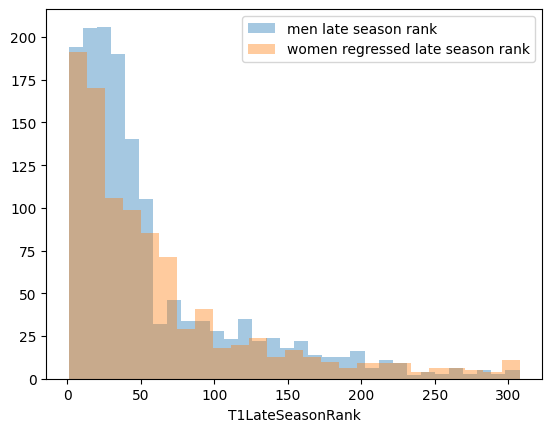

In [61]:
# W_tourney_results_with_regression_features[regression_target] = y_pred

seaborn.distplot(y_train, label="men late season rank", kde=False)
seaborn.distplot(y_pred, label="women regressed late season rank", kde=False)
plt.legend()

Let's add the predicted late season rank

In [62]:
W_tourney_results_with_regression_features[regression_target] = y_pred
W_tourney_results_with_regression_features

,Season,T1TeamID,T1Seed,T1_avg_Score,T1_avg_FTRate,T1_avg_eFG,T1_avg_DRRate,T1_avg_NE,T1_avg_TORate,T1_avg_ORRate,T1_Elo,T1LateSeasonRank
1449,2010,3124,4,71.885417,0.438309,0.484261,0.709735,19.510691,0.234018,0.364244,1863.237482,13.212036
1450,2010,3173,8,69.849573,0.315887,0.465242,0.705825,16.410575,0.233388,0.381488,1937.820211,29.966559
1451,2010,3181,2,71.593750,0.321778,0.457585,0.672744,20.580108,0.246742,0.443753,2059.950595,8.176143
1452,2010,3199,3,74.466667,0.377040,0.499876,0.674805,18.365868,0.257524,0.400785,2018.050836,11.131215
1453,2010,3207,5,67.352593,0.327538,0.450856,0.621107,14.495893,0.233491,0.406329,1965.635933,19.164240
...,...,...,...,...,...,...,...,...,...,...,...,...
4782,2025,3436,15,61.170139,0.215222,0.519036,0.754188,16.697647,0.181427,0.257243,1810.088294,130.583053
4783,2025,3333,14,60.855219,0.295727,0.460557,0.773530,2.441807,0.212226,0.279058,1822.185616,189.188400
4784,2025,3195,14,71.193548,0.304509,0.510371,0.784746,24.269429,0.171697,0.317831,2047.492066,65.413727
4785,2025,3329,7,76.444444,0.321820,0.509838,0.772743,20.701925,0.198596,0.326024,2069.316810,21.474490


In [63]:
ordinals_regression_features = pd.concat([
    M_tourney_results_with_regression_features,
    W_tourney_results_with_regression_features
    ])[["Season","T1TeamID","T1LateSeasonRank"]]

ordinals_regression_features

,Season,T1TeamID,T1LateSeasonRank
0,2003,1421,244.817235
1,2003,1112,1.701961
2,2003,1113,34.863636
3,2003,1141,57.610227
4,2003,1143,33.731250
...,...,...,...
4782,2025,3436,130.583053
4783,2025,3333,189.188400
4784,2025,3195,65.413727
4785,2025,3329,21.474490


In [64]:
ordinals_regression_features_T1 = ordinals_regression_features.copy()
ordinals_regression_features_T2 = ordinals_regression_features.copy()
ordinals_regression_features_T2.columns = [col.replace("T1", "T2") for col in ordinals_regression_features_T1.columns]

In [65]:
tourney_results_with_features.merge(ordinals_regression_features_T1,  
                                    on=["Season", "T1TeamID"], how="left").merge(ordinals_regression_features_T2,  
                                    on=["Season", "T2TeamID"], how="left")

,Season,T1TeamID,T2TeamID,Outcome,ScoreDiff,Category,T1Seed,T2Seed,SeedDiff,T1_avg_Opponent_NE,T1_avg_Opponent_DRRate,T1_avg_FTRate,T1_avg_FG%3,T1_avg_Opponent_FG%3,T1_avg_Opponent_AstTORate,T1_avg_TSDiff,T1_avg_FTRateDiff,T1_avg_Opponent_FGA,T1_avg_Opponent_FTM,T1_avg_Opponent_Score_adj,T1_avg_Opponent_FG%,T1_avg_eFGDiff,T1_avg_Opponent__Elo_Before,T1_avg_Opponent_StlTORate,T1_avg_Opponent_FTA,T1_avg_eFG,T1_avg_Opponent_Ast,T1_avg_Opponent_ORRate,T1_avg_Opponent_DR,T1_avg_PF,T1_avg_TORateDiff,T1_avg_Opponent_FTRate,T1_avg_Opponent_Score,T1_avg_Blk,T1_avg_Score_adj,T1_avg_FT%,T1_avg_FGA3,T1_avg_OR,T1_avg_Opponent_Poss,T1_avg_Opponent_eFG,T1_avg_Opponent_TORate,T1_avg_OE,T1_avg_Opponent_FGA3,T1_avg_OEDiff,T1_avg_FGM,T1_avg_AstTORate,T1_avg_Opponent_FT%,T1_avg_AstTORateDiff,T1_avg_FTA,T1_avg_DE,T1_avg_Opponent_PF,T1_avg_Opponent_Blk,T1_avg_Opponent_FGM3,T1_avg_StlTORate,T1_avg_Score,T1_avg_Opponent_TS,T1_avg_Poss,T1_avg_Ast,T1_avg_DRRate,T1_avg_Opponent_Stl,T1_avg_FGA,T1_avg__Elo_Before,T1_avg_NEDiff,T1_avg_DRRateDiff,T1_avg_TS,T1_avg_FG%,T1_avg_Opponent_OE,T1_avg_ORRateDiff,T1_avg_Score_adjDiff,T1_avg_Opponent_FGM,T1_avg_ORRate,T1_avg_FGM3,T1_avg_Opponent_TO,T1_avg_Opponent_OR,T1_avg_NumOT,T1_avg_TORate,T1_avg_DR,T1_avg_NE,T1_avg_Stl,T1_avg_DEDiff,T1_avg_StlTORateDiff,T1_avg_Opponent_DE,T1_avg_ScoreDiff,T1_avg_TO,T1_avg_FTM,T2_avg_Opponent_NE,T2_avg_Opponent_DRRate,T2_avg_FTRate,T2_avg_FG%3,T2_avg_Opponent_FG%3,T2_avg_Opponent_AstTORate,T2_avg_TSDiff,T2_avg_FTRateDiff,T2_avg_Opponent_FGA,T2_avg_Opponent_FTM,T2_avg_Opponent_Score_adj,T2_avg_Opponent_FG%,T2_avg_eFGDiff,T2_avg_Opponent__Elo_Before,T2_avg_Opponent_StlTORate,T2_avg_Opponent_FTA,T2_avg_eFG,T2_avg_Opponent_Ast,T2_avg_Opponent_ORRate,T2_avg_Opponent_DR,T2_avg_PF,T2_avg_TORateDiff,T2_avg_Opponent_FTRate,T2_avg_Opponent_Score,T2_avg_Blk,T2_avg_Score_adj,T2_avg_FT%,T2_avg_FGA3,T2_avg_OR,T2_avg_Opponent_Poss,T2_avg_Opponent_eFG,T2_avg_Opponent_TORate,T2_avg_OE,T2_avg_Opponent_FGA3,T2_avg_OEDiff,T2_avg_FGM,T2_avg_AstTORate,T2_avg_Opponent_FT%,T2_avg_AstTORateDiff,T2_avg_FTA,T2_avg_DE,T2_avg_Opponent_PF,T2_avg_Opponent_Blk,T2_avg_Opponent_FGM3,T2_avg_StlTORate,T2_avg_Score,T2_avg_Opponent_TS,T2_avg_Poss,T2_avg_Ast,T2_avg_DRRate,T2_avg_Opponent_Stl,T2_avg_FGA,T2_avg__Elo_Before,T2_avg_NEDiff,T2_avg_DRRateDiff,T2_avg_TS,T2_avg_FG%,T2_avg_Opponent_OE,T2_avg_ORRateDiff,T2_avg_Score_adjDiff,T2_avg_Opponent_FGM,T2_avg_ORRate,T2_avg_FGM3,T2_avg_Opponent_TO,T2_avg_Opponent_OR,T2_avg_NumOT,T2_avg_TORate,T2_avg_DR,T2_avg_NE,T2_avg_Stl,T2_avg_DEDiff,T2_avg_StlTORateDiff,T2_avg_Opponent_DE,T2_avg_ScoreDiff,T2_avg_TO,T2_avg_FTM,T1_Elo,T2_Elo,EloDiff,elo_win_prob,T1LateSeasonRank,T2LateSeasonRank
0,2003,1421,1411,win,7.111111,0,16,16,0,9.397573,0.652816,0.377214,0.363494,0.369765,1.381099,-0.010790,-0.000490,59.712644,15.004598,76.767243,0.454057,-0.026415,1458.045968,0.740523,22.157854,0.489800,15.563218,0.374381,22.401533,18.769349,0.046912,0.377704,76.947893,2.937165,69.795976,0.766142,17.658238,12.011494,68.567080,0.516215,0.183443,102.473386,20.307280,-9.397573,23.847510,0.916938,0.655791,-0.464162,20.428352,111.870959,18.265134,4.141762,7.459004,0.483437,69.615326,0.552615,68.547862,12.740230,0.625619,8.679693,55.639847,1363.080650,-18.795145,-0.027197,0.541825,0.432768,111.870959,-0.027197,-6.971267,27.242146,0.347184,6.348659,12.568582,13.463602,0.172414,0.230355,22.652874,-9.397573,6.927969,9.397573,-0.257086,102.473386,-7.332567,15.931034,15.571648,-4.197035,0.639867,0.529491,0.321414,0.333551,1.095844,0.019674,0.211347,60.140741,11.914815,70.672499,0.428747,0.011171,1337.275340,0.611741,18.655556,0.503036,13.718519,0.318277,22.781481,18.211111,0.016553,0.318144,70.585185,2.222222,72.446019,0.613745,18.437037,13.103704,70.726963,0.491864,0.201657,104.279156,23.051852,4.197035,24.644444,0.983780,0.615019,-0.112064,27.929630,100.082121,21.533333,2.596296,7.507407,0.454459,72.533333,0.520145,69.403852,14.140741,0.681723,7.977778,55.051852,1396.575755,8.394071,0.041855,0.539819,0.44

In [66]:
tourney_results_with_features = tourney_results_with_features.merge(ordinals_regression_features_T1,  
                                    on=["Season", "T1TeamID"], how="left").merge(ordinals_regression_features_T2,  
                                    on=["Season", "T2TeamID"], how="left")

tourney_results_with_features["LateSeasonRankDiff"] = tourney_results_with_features["T1LateSeasonRank"] - tourney_results_with_features["T2LateSeasonRank"]
tourney_results_with_features

,Season,T1TeamID,T2TeamID,Outcome,ScoreDiff,Category,T1Seed,T2Seed,SeedDiff,T1_avg_Opponent_NE,T1_avg_Opponent_DRRate,T1_avg_FTRate,T1_avg_FG%3,T1_avg_Opponent_FG%3,T1_avg_Opponent_AstTORate,T1_avg_TSDiff,T1_avg_FTRateDiff,T1_avg_Opponent_FGA,T1_avg_Opponent_FTM,T1_avg_Opponent_Score_adj,T1_avg_Opponent_FG%,T1_avg_eFGDiff,T1_avg_Opponent__Elo_Before,T1_avg_Opponent_StlTORate,T1_avg_Opponent_FTA,T1_avg_eFG,T1_avg_Opponent_Ast,T1_avg_Opponent_ORRate,T1_avg_Opponent_DR,T1_avg_PF,T1_avg_TORateDiff,T1_avg_Opponent_FTRate,T1_avg_Opponent_Score,T1_avg_Blk,T1_avg_Score_adj,T1_avg_FT%,T1_avg_FGA3,T1_avg_OR,T1_avg_Opponent_Poss,T1_avg_Opponent_eFG,T1_avg_Opponent_TORate,T1_avg_OE,T1_avg_Opponent_FGA3,T1_avg_OEDiff,T1_avg_FGM,T1_avg_AstTORate,T1_avg_Opponent_FT%,T1_avg_AstTORateDiff,T1_avg_FTA,T1_avg_DE,T1_avg_Opponent_PF,T1_avg_Opponent_Blk,T1_avg_Opponent_FGM3,T1_avg_StlTORate,T1_avg_Score,T1_avg_Opponent_TS,T1_avg_Poss,T1_avg_Ast,T1_avg_DRRate,T1_avg_Opponent_Stl,T1_avg_FGA,T1_avg__Elo_Before,T1_avg_NEDiff,T1_avg_DRRateDiff,T1_avg_TS,T1_avg_FG%,T1_avg_Opponent_OE,T1_avg_ORRateDiff,T1_avg_Score_adjDiff,T1_avg_Opponent_FGM,T1_avg_ORRate,T1_avg_FGM3,T1_avg_Opponent_TO,T1_avg_Opponent_OR,T1_avg_NumOT,T1_avg_TORate,T1_avg_DR,T1_avg_NE,T1_avg_Stl,T1_avg_DEDiff,T1_avg_StlTORateDiff,T1_avg_Opponent_DE,T1_avg_ScoreDiff,T1_avg_TO,T1_avg_FTM,T2_avg_Opponent_NE,T2_avg_Opponent_DRRate,T2_avg_FTRate,T2_avg_FG%3,T2_avg_Opponent_FG%3,T2_avg_Opponent_AstTORate,T2_avg_TSDiff,T2_avg_FTRateDiff,T2_avg_Opponent_FGA,T2_avg_Opponent_FTM,T2_avg_Opponent_Score_adj,T2_avg_Opponent_FG%,T2_avg_eFGDiff,T2_avg_Opponent__Elo_Before,T2_avg_Opponent_StlTORate,T2_avg_Opponent_FTA,T2_avg_eFG,T2_avg_Opponent_Ast,T2_avg_Opponent_ORRate,T2_avg_Opponent_DR,T2_avg_PF,T2_avg_TORateDiff,T2_avg_Opponent_FTRate,T2_avg_Opponent_Score,T2_avg_Blk,T2_avg_Score_adj,T2_avg_FT%,T2_avg_FGA3,T2_avg_OR,T2_avg_Opponent_Poss,T2_avg_Opponent_eFG,T2_avg_Opponent_TORate,T2_avg_OE,T2_avg_Opponent_FGA3,T2_avg_OEDiff,T2_avg_FGM,T2_avg_AstTORate,T2_avg_Opponent_FT%,T2_avg_AstTORateDiff,T2_avg_FTA,T2_avg_DE,T2_avg_Opponent_PF,T2_avg_Opponent_Blk,T2_avg_Opponent_FGM3,T2_avg_StlTORate,T2_avg_Score,T2_avg_Opponent_TS,T2_avg_Poss,T2_avg_Ast,T2_avg_DRRate,T2_avg_Opponent_Stl,T2_avg_FGA,T2_avg__Elo_Before,T2_avg_NEDiff,T2_avg_DRRateDiff,T2_avg_TS,T2_avg_FG%,T2_avg_Opponent_OE,T2_avg_ORRateDiff,T2_avg_Score_adjDiff,T2_avg_Opponent_FGM,T2_avg_ORRate,T2_avg_FGM3,T2_avg_Opponent_TO,T2_avg_Opponent_OR,T2_avg_NumOT,T2_avg_TORate,T2_avg_DR,T2_avg_NE,T2_avg_Stl,T2_avg_DEDiff,T2_avg_StlTORateDiff,T2_avg_Opponent_DE,T2_avg_ScoreDiff,T2_avg_TO,T2_avg_FTM,T1_Elo,T2_Elo,EloDiff,elo_win_prob,T1LateSeasonRank,T2LateSeasonRank,LateSeasonRankDiff
0,2003,1421,1411,win,7.111111,0,16,16,0,9.397573,0.652816,0.377214,0.363494,0.369765,1.381099,-0.010790,-0.000490,59.712644,15.004598,76.767243,0.454057,-0.026415,1458.045968,0.740523,22.157854,0.489800,15.563218,0.374381,22.401533,18.769349,0.046912,0.377704,76.947893,2.937165,69.795976,0.766142,17.658238,12.011494,68.567080,0.516215,0.183443,102.473386,20.307280,-9.397573,23.847510,0.916938,0.655791,-0.464162,20.428352,111.870959,18.265134,4.141762,7.459004,0.483437,69.615326,0.552615,68.547862,12.740230,0.625619,8.679693,55.639847,1363.080650,-18.795145,-0.027197,0.541825,0.432768,111.870959,-0.027197,-6.971267,27.242146,0.347184,6.348659,12.568582,13.463602,0.172414,0.230355,22.652874,-9.397573,6.927969,9.397573,-0.257086,102.473386,-7.332567,15.931034,15.571648,-4.197035,0.639867,0.529491,0.321414,0.333551,1.095844,0.019674,0.211347,60.140741,11.914815,70.672499,0.428747,0.011171,1337.275340,0.611741,18.655556,0.503036,13.718519,0.318277,22.781481,18.211111,0.016553,0.318144,70.585185,2.222222,72.446019,0.613745,18.437037,13.103704,70.726963,0.491864,0.201657,104.279156,23.051852,4.197035,24.644444,0.983780,0.615019,-0.112064,27.929630,100.082121,21.533333,2.596296,7.507407,0.454459,72.533333,0.520145,69.403852,14.140741,0.681723,7.977778,55.051852,1396.575755,8.394071,0.0

### Features selection:

In [67]:
features_to_use =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
'T1_avg_FT%',
'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
'T1_avg_ORRate',
'T1_avg_Opponent_Poss',
'T1_avg_FTRate',
'T1_avg_PF',
# 'T1_avg__Elo_Before',
'T1_avg_eFGDiff',
'T1_avg_Opponent_NE',
'T1_avg_Poss',
'T1_avg_Opponent_TO',
'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
'T1_avg_Opponent_StlTORate',
'T1_avg_Opponent_DRRate',
'T1_avg_eFG',
'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
'T1_avg_Opponent_eFG',
'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
'T1_avg_StlTORate',
'T1_avg_OE',
'T1_avg_FG%3',
'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
'T1_avg_Score_adj',
'T1_avg_FTA',
'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
'T1_avg_Opponent_FG%3',
'T1_avg_DR',
'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
'T1_avg_OR',
'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
'T1_avg_NE',
'T1_avg_StlTORateDiff',
'T1_avg_Opponent_TS',
'T1_avg_FG%',
'T1_avg_Opponent_Score_adj',
'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
'T1_avg_Ast',
'T1_avg_DE',
'T1_avg_TS',
'T2_avg_FT%',
'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
'T2_avg_ORRate',
'T2_avg_Opponent_Poss',
'T2_avg_FTRate',
'T2_avg_PF',
# 'T2_avg__Elo_Before',
'T2_avg_eFGDiff',
'T2_avg_Opponent_NE',
'T2_avg_Poss',
'T2_avg_Opponent_TO',
'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
'T2_avg_Opponent_StlTORate',
'T2_avg_Opponent_DRRate',
'T2_avg_eFG',
'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
'T2_avg_Opponent_eFG',
'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
'T2_avg_StlTORate',
'T2_avg_OE',
'T2_avg_FG%3',
'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
'T2_avg_Score_adj',
'T2_avg_FTA',
'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
'T2_avg_Opponent_FG%3',
'T2_avg_DR',
'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
'T2_avg_OR',
'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
'T2_avg_NE',
'T2_avg_StlTORateDiff',
'T2_avg_Opponent_TS',
'T2_avg_FG%',
'T2_avg_Opponent_Score_adj',
'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
'T2_avg_Ast',
'T2_avg_DE',
'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [68]:
features_to_use_only_diff =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
# 'T1Seed',
# 'T2Seed',
'SeedDiff',
# 'T1LateSeasonRank',
# 'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
'T1_avg_ORRateDiff',
# 'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
'T1_avg_OEDiff',
'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
'T1_avg_FTRateDiff',
'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
'T2_avg_ORRateDiff',
# 'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
'T2_avg_OEDiff',
'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
'T2_avg_FTRateDiff',
'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
# 'T1_Elo',
# 'T2_Elo',
'EloDiff',
# 'elo_win_prob'
]

In [69]:
minimal_raw_features_boxscore_to_use =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
'T1_avg_FGA3',
'T1_avg_Opponent_FGM3',
'T1_avg_Opponent_Score',
'T1_avg_Opponent_Blk',
'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
'T1_avg_FGM',
'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
'T1_avg_Opponent_DR',
'T1_avg_Opponent_FGM',
'T1_avg_NEDiff',
'T1_avg_Opponent_FTA',
'T1_avg_TO',
'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
'T1_avg_Stl',
'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
# 'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
'T1_avg_Blk',
'T1_avg_Opponent_PF',
'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
'T2_avg_FGA3',
'T2_avg_Opponent_FGM3',
'T2_avg_Opponent_Score',
'T2_avg_Opponent_Blk',
'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
'T2_avg_FGM',
'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
'T2_avg_Opponent_DR',
'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
'T2_avg_Opponent_FTA',
'T2_avg_TO',
'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
'T2_avg_Stl',
'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
# 'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
'T2_avg_Blk',
'T2_avg_Opponent_PF',
'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob']

pred = "ScoreDiff"

In [70]:
minimal_raw_features_to_use =  [
# 'Season',
# 'T1TeamID',
# 'T2TeamID',
# 'Outcome',
# 'ScoreDiff',
'Category',
'T1Seed',
'T2Seed',
'SeedDiff',
'T1LateSeasonRank',
'T2LateSeasonRank',
'LateSeasonRankDiff',
# 'T1_avg_FT%',
# 'T1_avg_TORate',
# 'T1_avg_Opponent__Elo_Before',
# 'T1_avg_Opponent_ORRate',
# 'T1_avg_FGA3',
# 'T1_avg_Opponent_FGM3',
# 'T1_avg_Opponent_Score',
# 'T1_avg_Opponent_Blk',
# 'T1_avg_FTM',
# 'T1_avg_ORRate',
# 'T1_avg_Opponent_Poss',
# 'T1_avg_FTRate',
# 'T1_avg_PF',
# 'T1_avg__Elo_Before',
# 'T1_avg_eFGDiff',
# 'T1_avg_Opponent_NE',
# 'T1_avg_Poss',
# 'T1_avg_Opponent_TO',
# 'T1_avg_Opponent_DE',
# 'T1_avg_Opponent_FTM',
# 'T1_avg_Opponent_StlTORate',
# 'T1_avg_Opponent_DRRate',
# 'T1_avg_eFG',
# 'T1_avg_Opponent_OR',
# 'T1_avg_TSDiff',
# 'T1_avg_Opponent_OE',
# 'T1_avg_NumOT',
# 'T1_avg_Opponent_eFG',
# 'T1_avg_Opponent_FTRate',
# 'T1_avg_FGA',
# 'T1_avg_Opponent_FG%',
# 'T1_avg_FGM',
# 'T1_avg_FGM3',
# 'T1_avg_TORateDiff',
# 'T1_avg_Opponent_DR',
# 'T1_avg_Opponent_FGM',
# 'T1_avg_NEDiff',
# 'T1_avg_Opponent_FTA',
# 'T1_avg_TO',
# 'T1_avg_Opponent_Ast',
# 'T1_avg_StlTORate',
# 'T1_avg_OE',
# 'T1_avg_FG%3',
# 'T1_avg_AstTORate',
# 'T1_avg_AstTORateDiff',
# 'T1_avg_Score_adj',
# 'T1_avg_FTA',
# 'T1_avg_Opponent_TORate',
# 'T1_avg_Stl',
# 'T1_avg_Opponent_Stl',
# 'T1_avg_Opponent_FG%3',
# 'T1_avg_DR',
# 'T1_avg_ORRateDiff',
'T1_avg_Score',
# 'T1_avg_Opponent_FGA',
# 'T1_avg_Opponent_FT%',
# 'T1_avg_Score_adjDiff',
# 'T1_avg_OR',
# 'T1_avg_Opponent_AstTORate',
# 'T1_avg_OEDiff',
# 'T1_avg_DRRateDiff',
'T1_avg_ScoreDiff',
# 'T1_avg_NE',
# 'T1_avg_StlTORateDiff',
# 'T1_avg_Opponent_TS',
# 'T1_avg_FG%',
# 'T1_avg_Opponent_Score_adj',
# 'T1_avg_DRRate',
# 'T1_avg_Blk',
# 'T1_avg_Opponent_PF',
# 'T1_avg_Opponent_FGA3',
# 'T1_avg_FTRateDiff',
# 'T1_avg_DEDiff',
# 'T1_avg_Ast',
# 'T1_avg_DE',
# 'T1_avg_TS',
# 'T2_avg_FT%',
# 'T2_avg_TORate',
# 'T2_avg_Opponent__Elo_Before',
# 'T2_avg_Opponent_ORRate',
# 'T2_avg_FGA3',
# 'T2_avg_Opponent_FGM3',
# 'T2_avg_Opponent_Score',
# 'T2_avg_Opponent_Blk',
# 'T2_avg_FTM',
# 'T2_avg_ORRate',
# 'T2_avg_Opponent_Poss',
# 'T2_avg_FTRate',
# 'T2_avg_PF',
# 'T2_avg__Elo_Before',
# 'T2_avg_eFGDiff',
# 'T2_avg_Opponent_NE',
# 'T2_avg_Poss',
# 'T2_avg_Opponent_TO',
# 'T2_avg_Opponent_DE',
# 'T2_avg_Opponent_FTM',
# 'T2_avg_Opponent_StlTORate',
# 'T2_avg_Opponent_DRRate',
# 'T2_avg_eFG',
# 'T2_avg_Opponent_OR',
# 'T2_avg_TSDiff',
# 'T2_avg_Opponent_OE',
# 'T2_avg_NumOT',
# 'T2_avg_Opponent_eFG',
# 'T2_avg_Opponent_FTRate',
# 'T2_avg_FGA',
# 'T2_avg_Opponent_FG%',
# 'T2_avg_FGM',
# 'T2_avg_FGM3',
# 'T2_avg_TORateDiff',
# 'T2_avg_Opponent_DR',
# 'T2_avg_Opponent_FGM',
# 'T2_avg_NEDiff',
# 'T2_avg_Opponent_FTA',
# 'T2_avg_TO',
# 'T2_avg_Opponent_Ast',
# 'T2_avg_StlTORate',
# 'T2_avg_OE',
# 'T2_avg_FG%3',
# 'T2_avg_AstTORate',
# 'T2_avg_AstTORateDiff',
# 'T2_avg_Score_adj',
# 'T2_avg_FTA',
# 'T2_avg_Opponent_TORate',
# 'T2_avg_Stl',
# 'T2_avg_Opponent_Stl',
# 'T2_avg_Opponent_FG%3',
# 'T2_avg_DR',
# 'T2_avg_ORRateDiff',
'T2_avg_Score',
# 'T2_avg_Opponent_FGA',
# 'T2_avg_Opponent_FT%',
# 'T2_avg_Score_adjDiff',
# 'T2_avg_OR',
# 'T2_avg_Opponent_AstTORate',
# 'T2_avg_OEDiff',
# 'T2_avg_DRRateDiff',
'T2_avg_ScoreDiff',
# 'T2_avg_NE',
# 'T2_avg_StlTORateDiff',
# 'T2_avg_Opponent_TS',
# 'T2_avg_FG%',
# 'T2_avg_Opponent_Score_adj',
# 'T2_avg_DRRate',
# 'T2_avg_Blk',
# 'T2_avg_Opponent_PF',
# 'T2_avg_Opponent_FGA3',
# 'T2_avg_FTRateDiff',
# 'T2_avg_DEDiff',
# 'T2_avg_Ast',
# 'T2_avg_DE',
# 'T2_avg_TS',
'T1_Elo',
'T2_Elo',
'EloDiff',
'elo_win_prob'
]

pred = "ScoreDiff"

### Regression on DiffScore

In [71]:
# we map "win", "lose" to 1, 0
tourney_results_with_features["Outcome"] = tourney_results_with_features["Outcome"].map(lambda x: 0 if x in ["lose", 0] else 1)

In [72]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# CONFIG
# =============================================================================

FEATURE_COLS = minimal_raw_features_to_use

TARGET_COL      = 'ScoreDiff'
TARGET_SEASON   = 2025
SEASONS         = sorted(tourney_results_with_features['Season'].unique())
SEASONS.remove(TARGET_SEASON)

# =============================================================================
# STEP 1 — XGBoost regression on ScoreDiff
# =============================================================================

def one_season_out_cv_regressor(df, feature_cols, target_col, params, verbose=False):

    oof_preds   = np.zeros(len(df))
    fold_scores = []

    for season in SEASONS:
        train = df[df['Season'] != season]
        val   = df[df['Season'] == season]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_val   = val[feature_cols].values
        y_val   = val[target_col].values

        model = xgb.XGBRegressor(
            **params,
            eval_metric='rmse',
            random_state=42,
        )
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

        preds = model.predict(X_val)
        oof_preds[val.index] = preds

        fold_scores.append({
            'season': season,
            'mae':  mean_absolute_error(y_val, preds),
            'rmse': np.sqrt(mean_squared_error(y_val, preds)),
        })

        if verbose:
            s = fold_scores[-1]
            print(f"Season {season} — MAE: {s['mae']:.2f}  RMSE: {s['rmse']:.2f}")

    scores_df = pd.DataFrame(fold_scores)
    if verbose:
        print(f"\nMean MAE  : {scores_df['mae'].mean():.2f} ± {scores_df['mae'].std():.2f}")
        print(f"Mean RMSE : {scores_df['rmse'].mean():.2f} ± {scores_df['rmse'].std():.2f}")

    return scores_df, oof_preds


# =============================================================================
# STEP 2 — Fit ScoreDiff → Probability conversion on OOF predictions
# =============================================================================

def fit_predict_score_to_prob(oof_score_diffs, actual_outcomes):
    """
    Fit a univariate spline.
    Using OOF predictions ensures no leakage.
    """
    max_score_difference = 25 # we clip the score difference predictions to 25 to avoid over-confidence
    dat = list(zip(oof_score_diffs, np.array(actual_outcomes)>0))
    dat = sorted(dat, key = lambda x: x[0])
    pred, label = list(zip(*dat))
    spline_model = UnivariateSpline(np.clip(pred, -max_score_difference, max_score_difference), label, k=5)
    oof_probs = np.clip(spline_model(np.clip(oof_score_diffs, -max_score_difference, max_score_difference)), 0.01, 0.99)

    return oof_probs



# =============================================================================
# STEP 3 — Optuna objective (now minimizes RMSE + variance)
# =============================================================================

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
    }

    scores_df, _ = one_season_out_cv_regressor(
        tourney_results_with_features,
        FEATURE_COLS,
        TARGET_COL,
        params,
    )

    mean_rmse = scores_df['rmse'].mean()
    std_rmse  = scores_df['rmse'].std()
    return mean_rmse + 0.5 * std_rmse


# =============================================================================
# STEP 4 — Full pipeline
# =============================================================================

# Optimize
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=2, show_progress_bar=True)
best_params = study.best_params

# Final CV with best params to get OOF predictions
print(f"\n---------- TRAIN STATS -------------")

scores_df, oof_score_diffs = one_season_out_cv_regressor(
    tourney_results_with_features, FEATURE_COLS, TARGET_COL, best_params, verbose=True
)

# Transform score_diffs in probabilities by fitting a univariate spline
actual_outcomes = tourney_results_with_features['Outcome'].values  # 1/0
oof_probs = fit_predict_score_to_prob(oof_score_diffs, actual_outcomes)

print(f"\nOOF log-loss : {log_loss(actual_outcomes, oof_probs):.4f}")
print(f"OOF Brier    : {brier_score_loss(actual_outcomes, oof_probs):.4f}")

# Train final model on TARGET_SEASON
X_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][FEATURE_COLS].values
y_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][TARGET_COL].values
X_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][FEATURE_COLS].values
y_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][TARGET_COL].values
actual_outcomes = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON]['Outcome'].values  # 1/0

final_model = xgb.XGBRegressor(**best_params, random_state=42)
final_model.fit(X_train, y_train)

y_pred  = final_model.predict(X_test)
mae     = mean_absolute_error(y_test, y_pred)
rmse    = np.sqrt(mean_squared_error(y_test, y_pred))

probs = fit_predict_score_to_prob(y_pred, actual_outcomes)

print(f"\n---------- TEST STATS -------------")
print(f"Season {TARGET_SEASON} — MAE: {mae:.2f}  RMSE: {rmse:.2f}")
print(f"\nlog-loss : {log_loss(actual_outcomes, probs):.4f}")
print(f"Brier    : {brier_score_loss(actual_outcomes, probs):.4f}")

# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature importances:\n", importance)

Best trial: 1. Best value: 12.4855: 100%|██████████| 2/2 [00:17<00:00,  8.62s/it]



---------- TRAIN STATS -------------
Season 2003 — MAE: 9.15  RMSE: 11.91
Season 2004 — MAE: 8.20  RMSE: 10.77
Season 2005 — MAE: 7.95  RMSE: 9.34
Season 2006 — MAE: 8.87  RMSE: 10.35
Season 2007 — MAE: 8.08  RMSE: 10.88
Season 2008 — MAE: 10.11  RMSE: 11.97
Season 2009 — MAE: 8.95  RMSE: 11.24
Season 2010 — MAE: 8.96  RMSE: 11.40
Season 2011 — MAE: 10.28  RMSE: 12.53
Season 2012 — MAE: 8.39  RMSE: 10.87
Season 2013 — MAE: 10.57  RMSE: 13.08
Season 2014 — MAE: 10.41  RMSE: 12.47
Season 2015 — MAE: 7.63  RMSE: 9.75
Season 2016 — MAE: 10.78  RMSE: 13.49
Season 2017 — MAE: 10.32  RMSE: 13.01
Season 2018 — MAE: 10.79  RMSE: 13.71
Season 2019 — MAE: 8.88  RMSE: 10.92
Season 2021 — MAE: 10.63  RMSE: 12.99
Season 2022 — MAE: 10.55  RMSE: 12.80
Season 2023 — MAE: 10.09  RMSE: 13.08
Season 2024 — MAE: 9.94  RMSE: 12.47

Mean MAE  : 9.50 ± 1.05
Mean RMSE : 11.86 ± 1.25

OOF log-loss : 0.5292
OOF Brier    : 0.1795

---------- TEST STATS -------------
Season 2025 — MAE: 10.42  RMSE: 13.42

log-lo

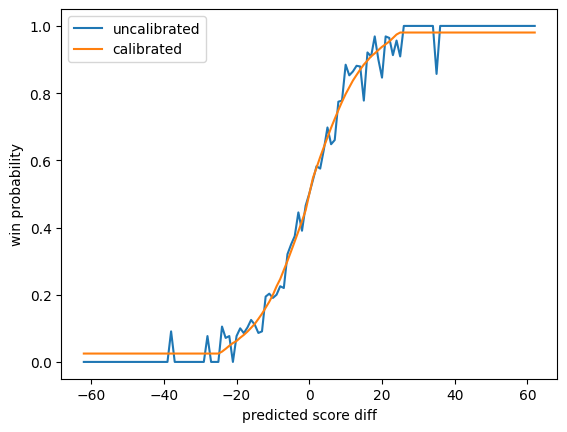

In [73]:
df = pd.DataFrame(
    {"Season": tourney_results_with_features["Season"], 
     "ScoreDiff": oof_score_diffs, 
     "Outcome": tourney_results_with_features["Outcome"], 
     "Category": tourney_results_with_features["Category"],
     "CalibratedPred" : oof_probs
     }
)
df["ScoreDiff"] = df["ScoreDiff"].astype(int)

predictions_df = df.groupby("ScoreDiff")[["Outcome","CalibratedPred"]].mean().reset_index()

plt.figure()
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["Outcome"], label="uncalibrated")
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["CalibratedPred"], label="calibrated")
plt.xlabel("predicted score diff")
plt.ylabel("win probability")
plt.show()

### Classification on Outcome

In [74]:
tourney_results_with_features["Outcome"] = tourney_results_with_features["Outcome"].map(lambda x: 0 if x in ["lose", 0] else 1)

In [75]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# =============================================================================
# CONFIG
# =============================================================================

FEATURE_COLS = minimal_raw_features_to_use
TARGET_COL = 'Outcome'   # 1 = T1 wins, 0 = T1 loses
TARGET_SEASON   = 2025

SEASONS = sorted(tourney_results_with_features['Season'].unique())
SEASONS.remove(TARGET_SEASON)

# =============================================================================
# CROSS-VALIDATION UTILITY
# =============================================================================

def one_season_out_cv(df, feature_cols, target_col, params, verbose=False):
    """
    Leave-one-season-out CV.
    Returns per-fold log-loss and brier score, plus out-of-fold predictions.
    """
    oof_preds  = np.zeros(len(df))
    fold_scores = []

    for season in SEASONS:
        train = df[df['Season'] != season]
        val   = df[df['Season'] == season]

        X_train = train[feature_cols].values
        y_train = train[target_col].values
        X_val   = val[feature_cols].values
        y_val   = val[target_col].values

        model = xgb.XGBClassifier(
            **params,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
        )
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        preds = model.predict_proba(X_val)[:, 1]
        oof_preds[val.index] = preds

        fold_ll = log_loss(y_val, preds)
        fold_bs = brier_score_loss(y_val, preds)
        fold_scores.append({'season': season, 'log_loss': fold_ll, 'brier': fold_bs})

        if verbose:
            print(f"Season {season} — log_loss: {fold_ll:.4f}  brier: {fold_bs:.4f}")

    scores_df = pd.DataFrame(fold_scores)
    if verbose:
        print(f"\nMean log_loss : {scores_df['log_loss'].mean():.4f} ± {scores_df['log_loss'].std():.4f}")
        print(f"Mean brier    : {scores_df['brier'].mean():.4f} ± {scores_df['brier'].std():.4f}")

    return scores_df, oof_preds

# =============================================================================
# OPTUNA OBJECTIVE
# =============================================================================

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),          # keep shallow — small dataset
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 30),  # strong regularization
        'gamma':            trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
    }

    scores_df, _ = one_season_out_cv(
        tourney_results_with_features,
        FEATURE_COLS,
        TARGET_COL,
        params,
    )

    # Penalize high variance across folds, not just mean loss
    mean_ll = scores_df['log_loss'].mean()
    std_ll  = scores_df['log_loss'].std()
    return mean_ll + 0.5 * std_ll   # Optuna minimizes this


# =============================================================================
# RUN OPTIMIZATION
# =============================================================================

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
study.optimize(objective, n_trials=2, show_progress_bar=True)

best_params = study.best_params

# =============================================================================
# FINAL EVALUATION WITH BEST PARAMS
# =============================================================================
print(f"\n---------- TRAIN STATS -------------")

scores_df, oof_preds = one_season_out_cv(
    tourney_results_with_features,
    FEATURE_COLS,
    TARGET_COL,
    best_params,
    verbose=True,
)

# =============================================================================
# TRAIN FINAL MODEL ON ALL DATA
# =============================================================================

X_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][FEATURE_COLS].values
y_train = tourney_results_with_features[tourney_results_with_features["Season"]!=TARGET_SEASON][TARGET_COL].values
X_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][FEATURE_COLS].values
y_test  = tourney_results_with_features[tourney_results_with_features["Season"]==TARGET_SEASON][TARGET_COL].values

final_model = xgb.XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
)
final_model.fit(X_train, y_train)

y_pred = final_model.predict_proba(X_test)[:, 1]

ll = log_loss(y_test, y_pred)
bs = brier_score_loss(y_test, y_pred)

print(f"\n---------- TEST STATS -------------")
print(f"Season {TARGET_SEASON} — log_loss: {ll:.4f}  brier: {bs:.4f}")

# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================

importance = pd.Series(
    final_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

print("\nFeature importances:\n", importance)

Best trial: 1. Best value: 0.567342: 100%|██████████| 2/2 [00:16<00:00,  8.03s/it]



---------- TRAIN STATS -------------
Season 2003 — log_loss: 0.5834  brier: 0.2063
Season 2004 — log_loss: 0.5739  brier: 0.2013
Season 2005 — log_loss: 0.5715  brier: 0.1976
Season 2006 — log_loss: 0.5672  brier: 0.1987
Season 2007 — log_loss: 0.4564  brier: 0.1523
Season 2008 — log_loss: 0.5069  brier: 0.1730
Season 2009 — log_loss: 0.4655  brier: 0.1555
Season 2010 — log_loss: 0.5166  brier: 0.1746
Season 2011 — log_loss: 0.5746  brier: 0.2019
Season 2012 — log_loss: 0.5176  brier: 0.1699
Season 2013 — log_loss: 0.5632  brier: 0.1884
Season 2014 — log_loss: 0.5176  brier: 0.1760
Season 2015 — log_loss: 0.4532  brier: 0.1490
Season 2016 — log_loss: 0.6172  brier: 0.2056
Season 2017 — log_loss: 0.5570  brier: 0.1901
Season 2018 — log_loss: 0.5978  brier: 0.1943
Season 2019 — log_loss: 0.4346  brier: 0.1462
Season 2021 — log_loss: 0.6085  brier: 0.2062
Season 2022 — log_loss: 0.5767  brier: 0.1898
Season 2023 — log_loss: 0.5871  brier: 0.1987
Season 2024 — log_loss: 0.4885  brier: 0.1

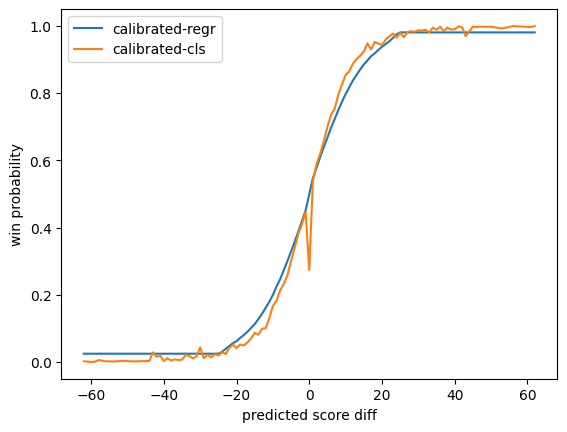

In [77]:
df["ClassificationPred"] = oof_preds
predictions_df = df.groupby("ScoreDiff")[["Outcome","CalibratedPred","ClassificationPred"]].mean().reset_index()

plt.figure()
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["CalibratedPred"], label="calibrated-regr")
seaborn.lineplot(x = predictions_df["ScoreDiff"], y=predictions_df["ClassificationPred"], label="calibrated-cls")
plt.xlabel("predicted score diff")
plt.ylabel("win probability")
plt.show()